In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d
import scipy
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
from collections import OrderedDict
import pyslha
import ROOT
import xml.etree.ElementTree as ET
import pylhe

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution

Welcome to JupyROOT 6.26/10


In [2]:
def readNumEvents(file):
    """
    Moderately efficent way to get the number of events stored in file.
    """
    
    with pylhe._extract_fileobj(file) as fileobj:
        nevts = sum(element.tag == "event" for event, element in ET.iterparse(fileobj, events=["end"]))
    return nevts

In [3]:
inputFiles = {
              'run_01_S': '../../DMSimp_S3D_uR_1j_meddecay/Events/run_01/unweighted_events.lhe.gz',
              'run_02_S': '../../DMSimp_S3D_uR_1j_meddecay/Events/run_02/unweighted_events.lhe.gz',
              'run_03_S': '../../DMSimp_S3D_uR_1j_meddecay/Events/run_03/unweighted_events.lhe.gz',
              'run_04_S': '../../DMSimp_S3D_uR_1j_meddecay/Events/run_04/unweighted_events.lhe.gz',
              'run_05_S': '../../DMSimp_S3D_uR_1j_meddecay/Events/run_05/unweighted_events.lhe.gz',
              'run_06_S': '../../DMSimp_S3D_uR_1j_meddecay/Events/run_06/unweighted_events.lhe.gz',
              'run_07_S': '../../DMSimp_S3D_uR_1j_meddecay/Events/run_07/unweighted_events.lhe.gz',
              'run_08_S': '../../DMSimp_S3D_uR_1j_meddecay/Events/run_08/unweighted_events.lhe.gz',
              'run_09_S': '../../DMSimp_S3D_uR_1j_meddecay/Events/run_09/unweighted_events.lhe.gz',
              'run_01_F': '../../DMSimp_F3S_uR_1j_meddecay/Events/run_01/unweighted_events.lhe.gz',
              'run_02_F': '../../DMSimp_F3S_uR_1j_meddecay/Events/run_02/unweighted_events.lhe.gz',
              'run_03_F': '../../DMSimp_F3S_uR_1j_meddecay/Events/run_03/unweighted_events.lhe.gz',
              'run_04_F': '../../DMSimp_F3S_uR_1j_meddecay/Events/run_04/unweighted_events.lhe.gz',
              'run_05_F': '../../DMSimp_F3S_uR_1j_meddecay/Events/run_05/unweighted_events.lhe.gz',
              'run_06_F': '../../DMSimp_F3S_uR_1j_meddecay/Events/run_06/unweighted_events.lhe.gz',
              'run_07_F': '../../DMSimp_F3S_uR_1j_meddecay/Events/run_07/unweighted_events.lhe.gz',
              'run_08_F': '../../DMSimp_F3S_uR_1j_meddecay/Events/run_08/unweighted_events.lhe.gz',
              'run_09_F': '../../DMSimp_F3S_uR_1j_meddecay/Events/run_09/unweighted_events.lhe.gz'
}

In [4]:
events = {}
nevents = {}
for label,f in inputFiles.items():   
    events[label] = pylhe.read_lhe_with_attributes(f)
    nevents[label] = readNumEvents(f)


In [5]:
parameters = {}
for label,file in inputFiles.items():
    banner = sorted(glob.glob(os.path.dirname(file)+'/*banner.txt'),key=os.path.getmtime,reverse=True)
    if len(banner) == 0:
        print('Banner not found for %s' %label)
    elif len(banner) > 1:        
        print('\n%i banner files found for %s. Using %s' 
              %(len(banner),label,os.path.basename(banner[0])))
    banner = banner[0]
    xtree = ET.parse(banner)
    xroot = xtree.getroot()
    slha = xroot.find('header').find('slha').text
    pars = pyslha.readSLHA(slha)
    
    if pars.blocks['MASS'][2000002] != 1e9:
        model = 'Scalar'
    if pars.blocks['MASS'][5920002] != 1e9:
        model = 'Fermion'
        
    if model == 'Scalar':
        mMed = pars.blocks['MASS'][2000002]
        mDM = pars.blocks['MASS'][57]
        g = pars.blocks['DMS3U'][1,1] # Mediator-quark vector coupling
        
    if model == 'Fermion':
        mMed = pars.blocks['MASS'][5920002]
        mDM = pars.blocks['MASS'][51]
        g = pars.blocks['DMF3U'][1,1] # Mediator-quark vector coupling
    
    parameters[label] = {'model': model, 'mMed' : mMed, 'mDM' : mDM, 
                         'g' : g}
    print(label,': mMed = %1.2f GeV, mDM = %1.2f GeV' %(mMed,mDM))

run_01_S : mMed = 1000.00 GeV, mDM = 10.00 GeV
run_02_S : mMed = 2000.00 GeV, mDM = 10.00 GeV
run_03_S : mMed = 5000.00 GeV, mDM = 10.00 GeV
run_04_S : mMed = 1000.00 GeV, mDM = 150.00 GeV
run_05_S : mMed = 2000.00 GeV, mDM = 150.00 GeV
run_06_S : mMed = 5000.00 GeV, mDM = 150.00 GeV
run_07_S : mMed = 1000.00 GeV, mDM = 500.00 GeV
run_08_S : mMed = 2000.00 GeV, mDM = 500.00 GeV
run_09_S : mMed = 5000.00 GeV, mDM = 500.00 GeV
run_01_F : mMed = 1000.00 GeV, mDM = 10.00 GeV
run_02_F : mMed = 2000.00 GeV, mDM = 10.00 GeV
run_03_F : mMed = 5000.00 GeV, mDM = 10.00 GeV
run_04_F : mMed = 1000.00 GeV, mDM = 150.00 GeV
run_05_F : mMed = 2000.00 GeV, mDM = 150.00 GeV
run_06_F : mMed = 5000.00 GeV, mDM = 150.00 GeV
run_07_F : mMed = 1000.00 GeV, mDM = 500.00 GeV
run_08_F : mMed = 2000.00 GeV, mDM = 500.00 GeV
run_09_F : mMed = 5000.00 GeV, mDM = 500.00 GeV


In [6]:
parameters

{'run_01_S': {'model': 'Scalar', 'mMed': 1000.0, 'mDM': 10.0, 'g': 1.0},
 'run_02_S': {'model': 'Scalar', 'mMed': 2000.0, 'mDM': 10.0, 'g': 1.0},
 'run_03_S': {'model': 'Scalar', 'mMed': 5000.0, 'mDM': 10.0, 'g': 1.0},
 'run_04_S': {'model': 'Scalar', 'mMed': 1000.0, 'mDM': 150.0, 'g': 1.0},
 'run_05_S': {'model': 'Scalar', 'mMed': 2000.0, 'mDM': 150.0, 'g': 1.0},
 'run_06_S': {'model': 'Scalar', 'mMed': 5000.0, 'mDM': 150.0, 'g': 1.0},
 'run_07_S': {'model': 'Scalar', 'mMed': 1000.0, 'mDM': 500.0, 'g': 1.0},
 'run_08_S': {'model': 'Scalar', 'mMed': 2000.0, 'mDM': 500.0, 'g': 1.0},
 'run_09_S': {'model': 'Scalar', 'mMed': 5000.0, 'mDM': 500.0, 'g': 1.0},
 'run_01_F': {'model': 'Fermion', 'mMed': 1000.0, 'mDM': 10.0, 'g': 1.0},
 'run_02_F': {'model': 'Fermion', 'mMed': 2000.0, 'mDM': 10.0, 'g': 1.0},
 'run_03_F': {'model': 'Fermion', 'mMed': 5000.0, 'mDM': 10.0, 'g': 1.0},
 'run_04_F': {'model': 'Fermion', 'mMed': 1000.0, 'mDM': 150.0, 'g': 1.0},
 'run_05_F': {'model': 'Fermion', 'mMed'

In [7]:
pTj1 = {label : np.array([]) for label in inputFiles}
weights = {label : np.array([]) for label in inputFiles}
met = {label : np.array([]) for label in inputFiles}
njets = {label : np.array([]) for label in inputFiles}
totalweight = {label : 0 for label in inputFiles}
negweight = {label : np.array([]) for label in inputFiles}

for label,evts in events.items():
   
    nevts = nevents[label]
    parameters[label]['Events'] = nevts
    n0 = 0
    
    for event in evts:

        particles = event.particles
       
        jets = [p for p in particles if abs(p.id) in [1,2,3,4,5,21] and p.status == 1]
#         med = [p for p in particles if abs(p.id) in [55] and p.status == 1]
        if parameters[label]['model'] == 'Scalar':
            dm = [p for p in particles if abs(p.id) in [57] and p.status == 1]
        if parameters[label]['model'] == 'Fermion':
            dm = [p for p in particles if abs(p.id) in [51] and p.status == 1]
    
        if len(dm) != 2:
            continue
            
        weight = event.eventinfo.weight/nevts
            
        if weight < 0:
            negw = weight
            negweight[label] += negw
            negweight[label] = np.append(negweight[label], negw)
            continue
            
        totalweight[label] += weight
            
        # Filter jets
        jetList = []
        for j in jets:
            pT = np.sqrt(j.px**2+j.py**2)
            p = np.sqrt(j.px**2+j.py**2+j.pz**2)
            pL = j.pz
            eta = 0.5*np.log((p+pL)/(p-pL))
            jetList.append(j)
            
        jetList = sorted(jetList, key = lambda j: np.sqrt(j.px**2+j.py**2), reverse=True)          
        
        MET = np.sqrt((dm[0].px+dm[1].px)**2 + (dm[0].py+dm[1].py)**2)
        if len(jetList) < 1: 
            n0 += 1
            continue
        pT1 = np.sqrt(jetList[0].px**2+jetList[0].py**2)
        
        # Store relevant data        
        njets[label] = np.append(njets[label],len(jets))
        pTj1[label] = np.append(pTj1[label],pT1)
        weights[label] = np.append(weights[label],weight)
        met[label] = np.append(met[label],MET)
    print(label, n0)
        

run_01_S 0
run_02_S 0
run_03_S 0
run_04_S 0
run_05_S 0
run_06_S 0
run_07_S 0
run_08_S 0
run_09_S 0
run_01_F 0
run_02_F 0
run_03_F 0
run_04_F 0
run_05_F 0
run_06_F 0
run_07_F 0
run_08_F 0
run_09_F 0


In [8]:
for label in weights:
    frac = np.array(len(negweight[label]))/nevents[label]*100
    print(label, 'Fraction of negative events: %1.2f%%' 
          %frac)

run_01_S Fraction of negative events: 0.00%
run_02_S Fraction of negative events: 0.00%
run_03_S Fraction of negative events: 0.00%
run_04_S Fraction of negative events: 0.00%
run_05_S Fraction of negative events: 0.00%
run_06_S Fraction of negative events: 0.00%
run_07_S Fraction of negative events: 0.00%
run_08_S Fraction of negative events: 0.00%
run_09_S Fraction of negative events: 0.00%
run_01_F Fraction of negative events: 0.00%
run_02_F Fraction of negative events: 0.00%
run_03_F Fraction of negative events: 0.00%
run_04_F Fraction of negative events: 0.00%
run_05_F Fraction of negative events: 0.00%
run_06_F Fraction of negative events: 0.00%
run_07_F Fraction of negative events: 0.00%
run_08_F Fraction of negative events: 0.00%
run_09_F Fraction of negative events: 0.00%


In [9]:
for label, w in weights.items():
    print(len(weights[label]))

100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
100000
100000


In [10]:
nevents

{'run_01_S': 100000,
 'run_02_S': 100000,
 'run_03_S': 100000,
 'run_04_S': 100000,
 'run_05_S': 100000,
 'run_06_S': 100000,
 'run_07_S': 100000,
 'run_08_S': 100000,
 'run_09_S': 100000,
 'run_01_F': 100000,
 'run_02_F': 100000,
 'run_03_F': 100000,
 'run_04_F': 100000,
 'run_05_F': 100000,
 'run_06_F': 100000,
 'run_07_F': 100000,
 'run_08_F': 100000,
 'run_09_F': 100000}

In [11]:
for label,w in totalweight.items():
    print(label,'total cross-section = %1.3e pb' %w)
colors = {label : sns.color_palette('deep', n_colors=23)[i] for i,label in enumerate(weights.keys())}    

run_01_S total cross-section = 1.147e-01 pb
run_02_S total cross-section = 4.688e-03 pb
run_03_S total cross-section = 1.026e-04 pb
run_04_S total cross-section = 9.748e-02 pb
run_05_S total cross-section = 3.634e-03 pb
run_06_S total cross-section = 8.260e-05 pb
run_07_S total cross-section = 4.048e-02 pb
run_08_S total cross-section = 1.798e-03 pb
run_09_S total cross-section = 3.389e-05 pb
run_01_F total cross-section = 1.409e-01 pb
run_02_F total cross-section = 2.106e-03 pb
run_03_F total cross-section = 4.104e-07 pb
run_04_F total cross-section = 1.230e-01 pb
run_05_F total cross-section = 1.942e-03 pb
run_06_F total cross-section = 3.889e-07 pb
run_07_F total cross-section = 6.095e-02 pb
run_08_F total cross-section = 1.288e-03 pb
run_09_F total cross-section = 2.787e-07 pb


In [12]:
parameters

{'run_01_S': {'model': 'Scalar',
  'mMed': 1000.0,
  'mDM': 10.0,
  'g': 1.0,
  'Events': 100000},
 'run_02_S': {'model': 'Scalar',
  'mMed': 2000.0,
  'mDM': 10.0,
  'g': 1.0,
  'Events': 100000},
 'run_03_S': {'model': 'Scalar',
  'mMed': 5000.0,
  'mDM': 10.0,
  'g': 1.0,
  'Events': 100000},
 'run_04_S': {'model': 'Scalar',
  'mMed': 1000.0,
  'mDM': 150.0,
  'g': 1.0,
  'Events': 100000},
 'run_05_S': {'model': 'Scalar',
  'mMed': 2000.0,
  'mDM': 150.0,
  'g': 1.0,
  'Events': 100000},
 'run_06_S': {'model': 'Scalar',
  'mMed': 5000.0,
  'mDM': 150.0,
  'g': 1.0,
  'Events': 100000},
 'run_07_S': {'model': 'Scalar',
  'mMed': 1000.0,
  'mDM': 500.0,
  'g': 1.0,
  'Events': 100000},
 'run_08_S': {'model': 'Scalar',
  'mMed': 2000.0,
  'mDM': 500.0,
  'g': 1.0,
  'Events': 100000},
 'run_09_S': {'model': 'Scalar',
  'mMed': 5000.0,
  'mDM': 500.0,
  'g': 1.0,
  'Events': 100000},
 'run_01_F': {'model': 'Fermion',
  'mMed': 1000.0,
  'mDM': 10.0,
  'g': 1.0,
  'Events': 100000},
 'r

In [13]:
mDM_list = []
for label in parameters.keys():
    mDM_list.append(parameters[label]['mDM'])

In [14]:
mDM_unique = list(set(mDM_list))

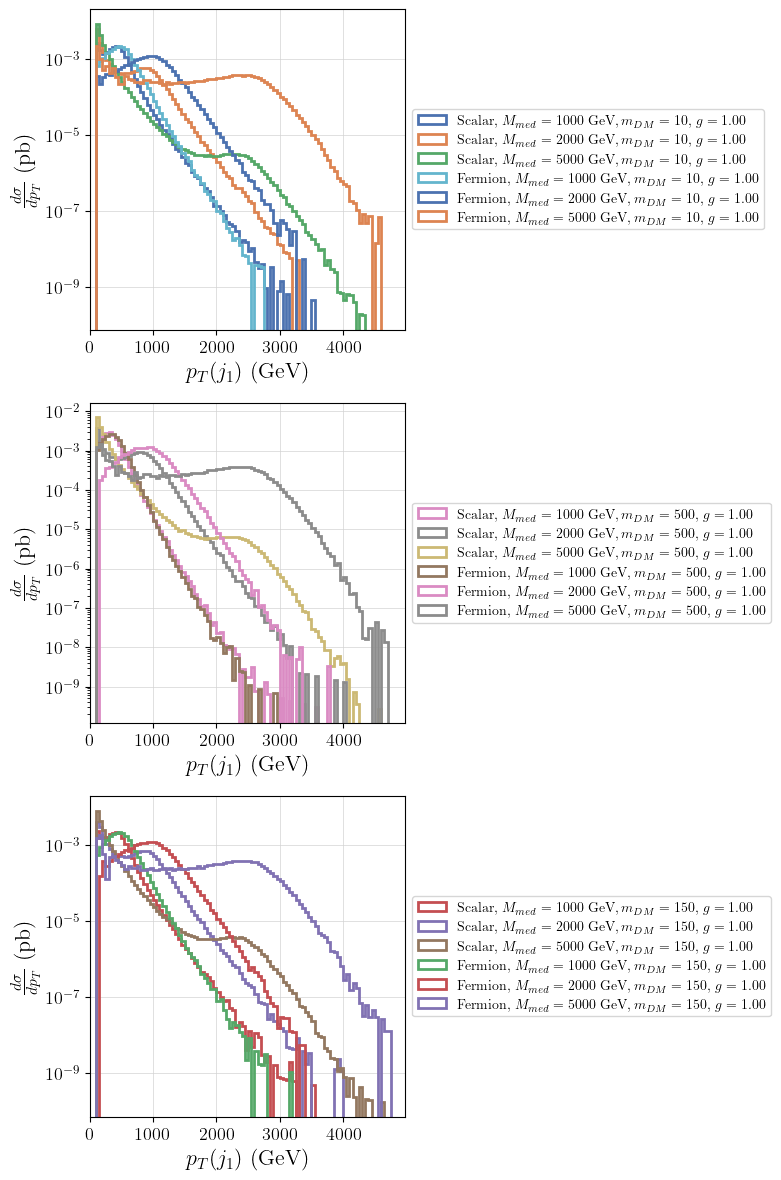

In [15]:
fig, ax = plt.subplots(len(mDM_unique), 1, figsize=(8,12))

for i, mass in enumerate(mDM_unique):
    for label in parameters.keys():
        if parameters[label]['mDM'] != mass: continue
        binc,binEdges,patches = ax[i].hist(pTj1[label],bins=np.linspace(0,5000,101),
                                   label=r'%s, $M_{med} = %1.0f$ GeV$, m_{DM} = %1.0f$, $g = %1.2f$'%(parameters[label]['model'], parameters[label]['mMed'], parameters[label]['mDM'], parameters[label]['g']),
                                         histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
#         errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2)
#         errorc = np.sqrt(errorc2)
#         binCenter = (binEdges[0:-1]+binEdges[1:])/2.
#         ax[i].errorbar(binCenter,binc,yerr = errorc, marker = '.', 
#                      drawstyle = 'steps-mid', color=colors[label])

    
    ax[i].set_yscale('log')
    # plt.ylim(1e-8,5e-5)
    ax[i].set_xlabel(r'$p_T(j_1)$ (GeV)')
    ax[i].set_ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
    ax[i].set_xlim(0,pTj1[label].max()-100)
    ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

plt.show()

In [16]:
parameters

{'run_01_S': {'model': 'Scalar',
  'mMed': 1000.0,
  'mDM': 10.0,
  'g': 1.0,
  'Events': 100000},
 'run_02_S': {'model': 'Scalar',
  'mMed': 2000.0,
  'mDM': 10.0,
  'g': 1.0,
  'Events': 100000},
 'run_03_S': {'model': 'Scalar',
  'mMed': 5000.0,
  'mDM': 10.0,
  'g': 1.0,
  'Events': 100000},
 'run_04_S': {'model': 'Scalar',
  'mMed': 1000.0,
  'mDM': 150.0,
  'g': 1.0,
  'Events': 100000},
 'run_05_S': {'model': 'Scalar',
  'mMed': 2000.0,
  'mDM': 150.0,
  'g': 1.0,
  'Events': 100000},
 'run_06_S': {'model': 'Scalar',
  'mMed': 5000.0,
  'mDM': 150.0,
  'g': 1.0,
  'Events': 100000},
 'run_07_S': {'model': 'Scalar',
  'mMed': 1000.0,
  'mDM': 500.0,
  'g': 1.0,
  'Events': 100000},
 'run_08_S': {'model': 'Scalar',
  'mMed': 2000.0,
  'mDM': 500.0,
  'g': 1.0,
  'Events': 100000},
 'run_09_S': {'model': 'Scalar',
  'mMed': 5000.0,
  'mDM': 500.0,
  'g': 1.0,
  'Events': 100000},
 'run_01_F': {'model': 'Fermion',
  'mMed': 1000.0,
  'mDM': 10.0,
  'g': 1.0,
  'Events': 100000},
 'r

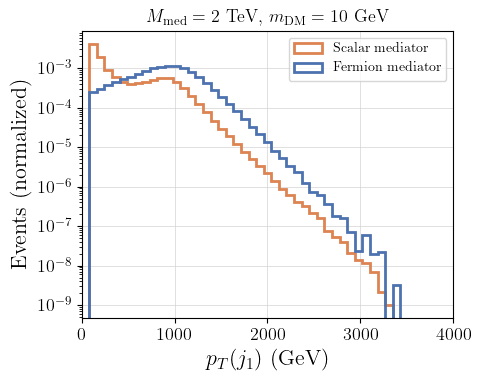

In [31]:
for label in parameters.keys():
#     if parameters[label]['model'] != 'Scalar': continue
    if parameters[label]['mDM'] != 10.: continue
    if parameters[label]['mMed'] != 2000.: continue
    plt.hist(pTj1[label],bins=np.linspace(0,4000,50),
               label=r'%s mediator'%(parameters[label]['model']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    
plt.legend()
plt.yscale('log')
plt.ylabel('Events (normalized)')
plt.xlabel(r'$p_{T}(j_{1})$ (GeV)')
plt.xlim(0,4000)
plt.title(r'$M_{\rm med} = 2$ TeV, $m_{\rm DM} = 10$ GeV')
plt.tight_layout()

plt.savefig('./figures/full_mdm_10_mmed_2TeV.png')
plt.show()

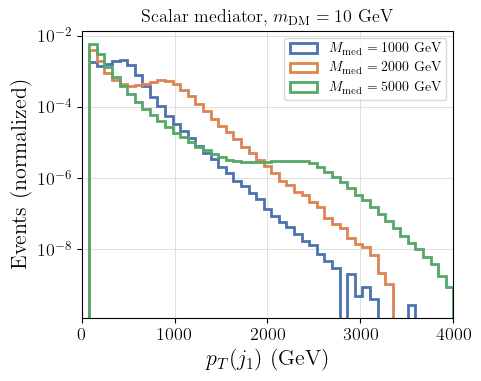

In [17]:
for label in parameters.keys():
    if parameters[label]['model'] != 'Scalar': continue
    if parameters[label]['mDM'] != 10.: continue
    plt.hist(pTj1[label],bins=np.linspace(0,4000,50),
               label=r'$M_{\rm med} = %1.0f$ GeV'%(parameters[label]['mMed']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    
plt.legend()
plt.yscale('log')
plt.ylabel('Events (normalized)')
plt.xlabel(r'$p_{T}(j_{1})$ (GeV)')
plt.xlim(0,4000)
plt.title(r'Scalar mediator, $m_{\rm DM} = 10$ GeV')
plt.tight_layout()

plt.savefig('./figures/scalar_full_mdm_10.png')
plt.show()

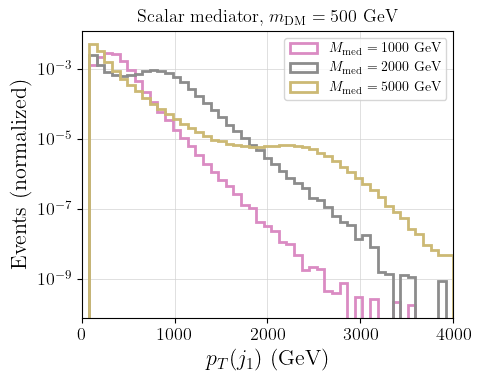

In [18]:
for label in parameters.keys():
    if parameters[label]['model'] != 'Scalar': continue
    if parameters[label]['mDM'] != 500.: continue
    plt.hist(pTj1[label],bins=np.linspace(0,4000,50),
               label=r'$M_{\rm med} = %1.0f$ GeV'%(parameters[label]['mMed']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    
plt.legend()
plt.yscale('log')
plt.ylabel('Events (normalized)')
plt.xlabel(r'$p_{T}(j_{1})$ (GeV)')
plt.xlim(0,4000)
plt.title(r'Scalar mediator, $m_{\rm DM} = 500$ GeV')
plt.tight_layout()

plt.savefig('./figures/scalar_full_mdm_500.png')
plt.show()

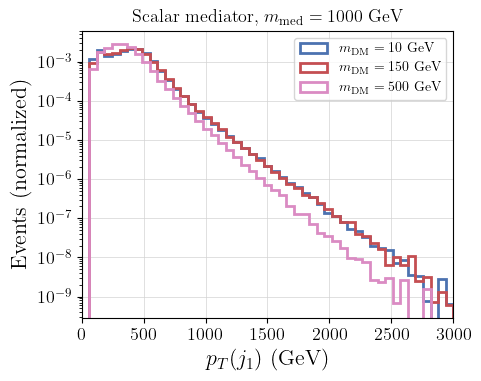

In [19]:
for label in parameters.keys():
    if parameters[label]['model'] != 'Scalar': continue
    if parameters[label]['mMed'] != 1000.: continue
    plt.hist(pTj1[label],bins=np.linspace(0,3000,50),
               label=r'$m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mDM']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    
plt.legend()
plt.yscale('log')
plt.ylabel('Events (normalized)')
plt.xlabel(r'$p_{T}(j_{1})$ (GeV)')
plt.xlim(0,3000)
plt.title(r'Scalar mediator, $m_{\rm med} = 1000$ GeV')
plt.tight_layout()

# plt.savefig('./figures/fermion_full_mdm_150.png')
plt.show()

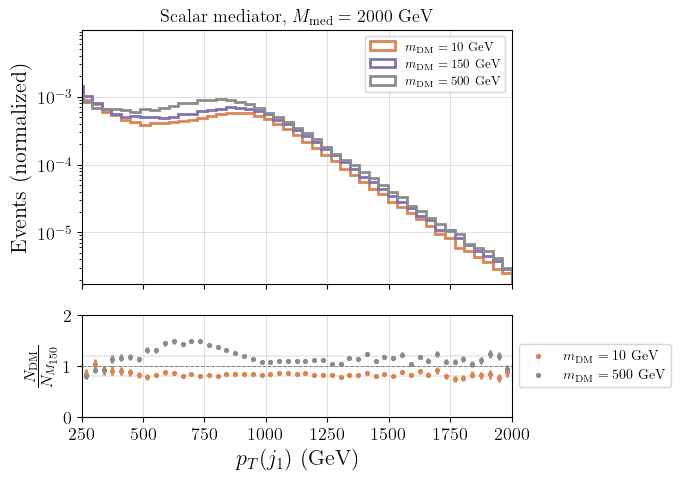

In [21]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(7,5))

mass = 2000.0


for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
    if parameters[label]['model'] != 'Scalar': continue
    if parameters[label]['mDM'] != 150.0: continue
    bin_ref, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50),weights=weights[label], density=True)
    bin_ref_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50),weights=weights[label], density=False)
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50),weights=weights[label]**2, density=False)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['model'] != 'Scalar': continue
    
    if parameters[label]['mMed'] != mass: continue
#     if parameters[label]['mDM'] == 250.0: continue
#     if parameters[label]['mMed'] == 500.0: continue
#     if parameters[label]['mMed'] == 2000.0: continue
#     if parameters[label]['mMed'] == 5000.0: continue
    
    ax[0].hist(pTj1[label],bins=np.linspace(100,2000,50),
               label=r'$m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mDM']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    binc,binEdges = np.histogram(pTj1[label],bins=np.linspace(250,2000,50), weights=weights[label], density=True)
    binc_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50), weights=weights[label], density=False)
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2, density=False)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
#     ax[0].errorbar(binCenter, binc, yerr = errorc, marker = '.', drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mDM'] == 150.0: continue
    
#     if parameters[label]['mMed'] == mass: continue
#     if parameters[label]['mMed'] == 1000.0: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratiok = k*binc_nodensity/bin_ref_nodensity
    ratio = binc/bin_ref
    ratioErr = np.sqrt(errorc**2 + ratiok**2 * err_ref**2)/bin_ref_nodensity
    
    
    
    ax[1].scatter(binCenter, ratiok, marker='.', s=30, color=colors[label],
                  label=r'$m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratiok, yerr = ratioErr, fmt='.', color=colors[label])
    

ax[0].set_title(r'Scalar mediator, $M_{\rm med} = 2000$ GeV')
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'Events (normalized)')
plt.xlim(250,2000)
ax[0].legend(loc='upper right', fontsize='x-small')
ax[1].set_ylim(0.,2.)
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel(r'$\frac{N_{\rm DM}}{N_{M_{150}}}$')
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
 

plt.tight_layout()

plt.savefig('./figures/scalar_full_mmed_2TeV.png')
plt.show()

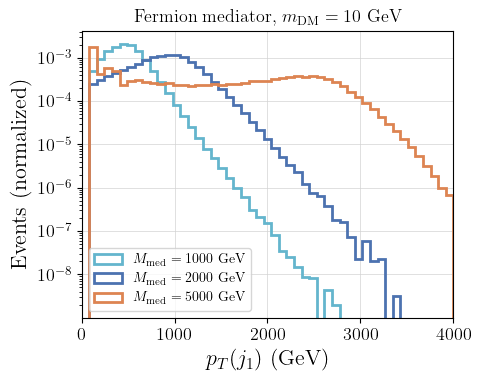

In [37]:
for label in parameters.keys():
    if parameters[label]['model'] != 'Fermion': continue
    if parameters[label]['mDM'] != 10.: continue
    plt.hist(pTj1[label],bins=np.linspace(0,4000,50),
               label=r'$M_{\rm med} = %1.0f$ GeV'%(parameters[label]['mMed']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    
plt.legend()
plt.yscale('log')
plt.ylabel('Events (normalized)')
plt.xlabel(r'$p_{T}(j_{1})$ (GeV)')
plt.xlim(0,4000)
plt.title(r'Fermion mediator, $m_{\rm DM} = 10$ GeV')
plt.tight_layout()

plt.savefig('./figures/fermion_full_mdm_10.png')
plt.show()

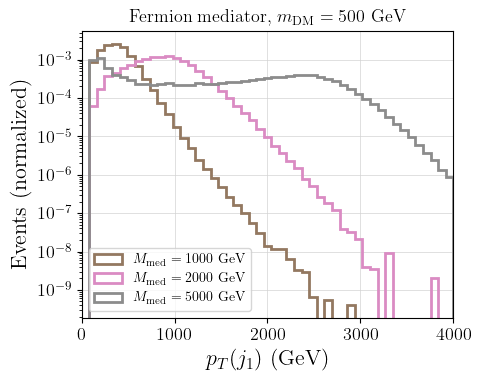

In [57]:
for label in parameters.keys():
    if parameters[label]['model'] != 'Fermion': continue
    if parameters[label]['mDM'] != 500.: continue
    plt.hist(pTj1[label],bins=np.linspace(0,4000,50),
               label=r'$M_{\rm med} = %1.0f$ GeV'%(parameters[label]['mMed']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    
plt.legend()
plt.yscale('log')
plt.ylabel('Events (normalized)')
plt.xlabel(r'$p_{T}(j_{1})$ (GeV)')
plt.xlim(0,4000)
plt.title(r'Fermion mediator, $m_{\rm DM} = 500$ GeV')
plt.tight_layout()

plt.savefig('./figures/fermion_full_mdm_500.png')
plt.show()

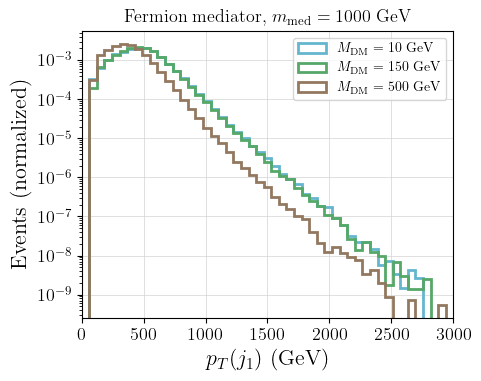

In [45]:
for label in parameters.keys():
    if parameters[label]['model'] != 'Fermion': continue
    if parameters[label]['mMed'] != 1000.: continue
    plt.hist(pTj1[label],bins=np.linspace(0,3000,50),
               label=r'$M_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mDM']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    
plt.legend()
plt.yscale('log')
plt.ylabel('Events (normalized)')
plt.xlabel(r'$p_{T}(j_{1})$ (GeV)')
plt.xlim(0,3000)
plt.title(r'Fermion mediator, $m_{\rm med} = 1000$ GeV')
plt.tight_layout()

# plt.savefig('./figures/fermion_full_mdm_150.png')
plt.show()

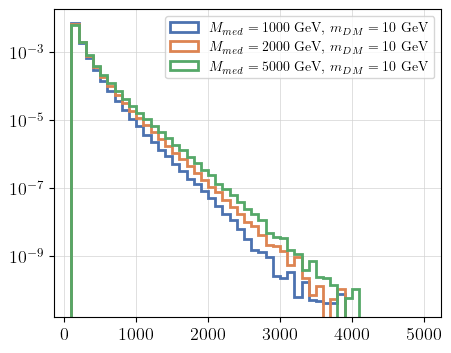

In [25]:
for label in parameters.keys():
    if parameters[label]['model'] != 'Scalar': continue
    if parameters[label]['mDM'] != 10.: continue
    plt.hist(pTj1[label],bins=np.linspace(100,5000,50),
               label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    
plt.legend()
plt.yscale('log')
plt.show()

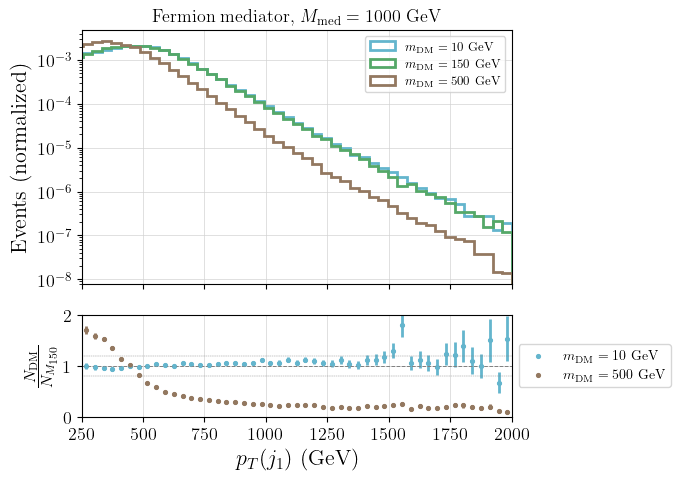

In [55]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(7,5))

mass = 1000.0


for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
    if parameters[label]['model'] != 'Fermion': continue
    if parameters[label]['mDM'] != 150.0: continue
    bin_ref, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50),weights=weights[label], density=True)
    bin_ref_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50),weights=weights[label], density=False)
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50),weights=weights[label]**2, density=False)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['model'] != 'Fermion': continue
    
    if parameters[label]['mMed'] != mass: continue
#     if parameters[label]['mDM'] == 250.0: continue
#     if parameters[label]['mMed'] == 500.0: continue
#     if parameters[label]['mMed'] == 2000.0: continue
#     if parameters[label]['mMed'] == 5000.0: continue
    
    ax[0].hist(pTj1[label],bins=np.linspace(100,2000,50),
               label=r'$m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mDM']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    binc,binEdges = np.histogram(pTj1[label],bins=np.linspace(250,2000,50), weights=weights[label], density=True)
    binc_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50), weights=weights[label], density=False)
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2, density=False)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
#     ax[0].errorbar(binCenter, binc, yerr = errorc, marker = '.', drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mDM'] == 150.0: continue
    
#     if parameters[label]['mMed'] == mass: continue
#     if parameters[label]['mMed'] == 1000.0: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratiok = k*binc_nodensity/bin_ref_nodensity
    ratio = binc/bin_ref
    ratioErr = np.sqrt(errorc**2 + ratiok**2 * err_ref**2)/bin_ref_nodensity
    
    
    
    ax[1].scatter(binCenter, ratiok, marker='.', s=30, color=colors[label],
                  label=r'$m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratiok, yerr = ratioErr, fmt='.', color=colors[label])
    

ax[0].set_title(r'Fermion mediator, $M_{\rm med} = 1000$ GeV')
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'Events (normalized)')
plt.xlim(250,2000)
ax[0].legend(loc='upper right', fontsize='x-small')
ax[1].set_ylim(0.,2.)
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel(r'$\frac{N_{\rm DM}}{N_{M_{150}}}$')
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
 

plt.tight_layout()

plt.savefig('./figures/fermion_full_mmed_1TeV.png')
plt.show()

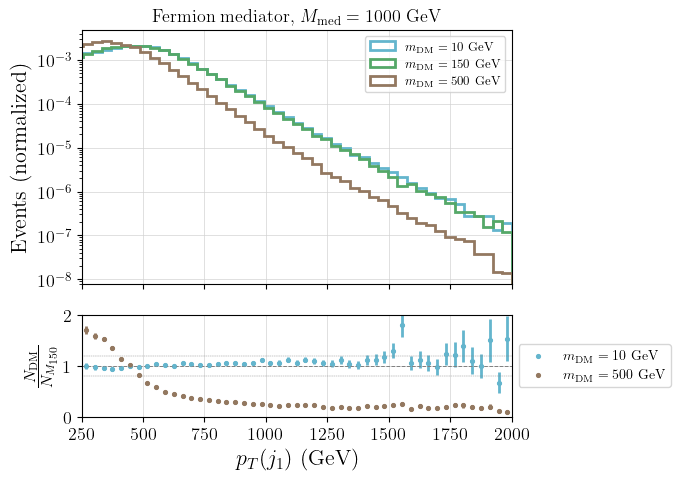

In [55]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(7,5))

mass = 1000.0


for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
    if parameters[label]['model'] != 'Fermion': continue
    if parameters[label]['mDM'] != 150.0: continue
    bin_ref, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50),weights=weights[label], density=True)
    bin_ref_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50),weights=weights[label], density=False)
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50),weights=weights[label]**2, density=False)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['model'] != 'Fermion': continue
    
    if parameters[label]['mMed'] != mass: continue
#     if parameters[label]['mDM'] == 250.0: continue
#     if parameters[label]['mMed'] == 500.0: continue
#     if parameters[label]['mMed'] == 2000.0: continue
#     if parameters[label]['mMed'] == 5000.0: continue
    
    ax[0].hist(pTj1[label],bins=np.linspace(100,2000,50),
               label=r'$m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mDM']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    binc,binEdges = np.histogram(pTj1[label],bins=np.linspace(250,2000,50), weights=weights[label], density=True)
    binc_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50), weights=weights[label], density=False)
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2, density=False)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
#     ax[0].errorbar(binCenter, binc, yerr = errorc, marker = '.', drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mDM'] == 150.0: continue
    
#     if parameters[label]['mMed'] == mass: continue
#     if parameters[label]['mMed'] == 1000.0: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratiok = k*binc_nodensity/bin_ref_nodensity
    ratio = binc/bin_ref
    ratioErr = np.sqrt(errorc**2 + ratiok**2 * err_ref**2)/bin_ref_nodensity
    
    
    
    ax[1].scatter(binCenter, ratiok, marker='.', s=30, color=colors[label],
                  label=r'$m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratiok, yerr = ratioErr, fmt='.', color=colors[label])
    

ax[0].set_title(r'Fermion mediator, $M_{\rm med} = 1000$ GeV')
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'Events (normalized)')
plt.xlim(250,2000)
ax[0].legend(loc='upper right', fontsize='x-small')
ax[1].set_ylim(0.,2.)
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel(r'$\frac{N_{\rm DM}}{N_{M_{150}}}$')
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
 

plt.tight_layout()

plt.savefig('./figures/fermion_full_mmed_1TeV.png')
plt.show()

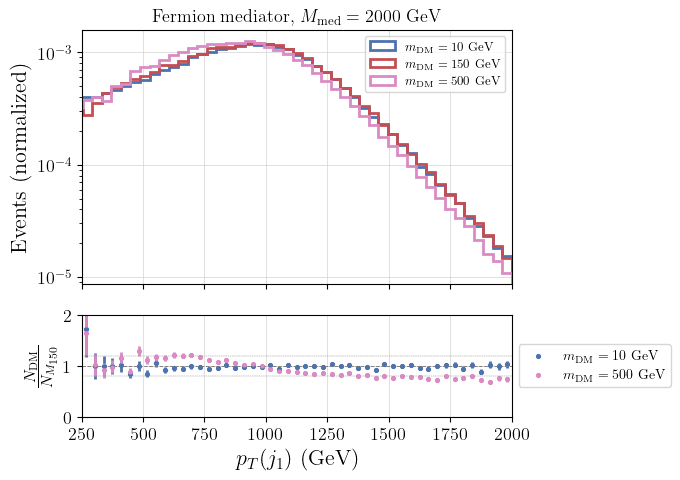

In [56]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(7,5))

mass = 2000.0


for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
    if parameters[label]['model'] != 'Fermion': continue
    if parameters[label]['mDM'] != 150.0: continue
    bin_ref, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50),weights=weights[label], density=True)
    bin_ref_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50),weights=weights[label], density=False)
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50),weights=weights[label]**2, density=False)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['model'] != 'Fermion': continue
    
    if parameters[label]['mMed'] != mass: continue
#     if parameters[label]['mDM'] == 250.0: continue
#     if parameters[label]['mMed'] == 500.0: continue
#     if parameters[label]['mMed'] == 2000.0: continue
#     if parameters[label]['mMed'] == 5000.0: continue
    
    ax[0].hist(pTj1[label],bins=np.linspace(100,2000,50),
               label=r'$m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mDM']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    binc,binEdges = np.histogram(pTj1[label],bins=np.linspace(250,2000,50), weights=weights[label], density=True)
    binc_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(250,2000,50), weights=weights[label], density=False)
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2, density=False)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
#     ax[0].errorbar(binCenter, binc, yerr = errorc, marker = '.', drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mDM'] == 150.0: continue
    
#     if parameters[label]['mMed'] == mass: continue
#     if parameters[label]['mMed'] == 1000.0: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratiok = k*binc_nodensity/bin_ref_nodensity
    ratio = binc/bin_ref
    ratioErr = np.sqrt(errorc**2 + ratiok**2 * err_ref**2)/bin_ref_nodensity
    
    
    
    ax[1].scatter(binCenter, ratiok, marker='.', s=30, color=colors[label],
                  label=r'$m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratiok, yerr = ratioErr, fmt='.', color=colors[label])
    

ax[0].set_title(r'Fermion mediator, $M_{\rm med} = 2000$ GeV')
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'Events (normalized)')
plt.xlim(250,2000)
ax[0].legend(loc='upper right', fontsize='x-small')
ax[1].set_ylim(0.,2.)
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel(r'$\frac{N_{\rm DM}}{N_{M_{150}}}$')
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
 

plt.tight_layout()

plt.savefig('./figures/fermion_full_mmed_2TeV.png')
plt.show()

/tmp/ipykernel_55906/2558619827.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc='upper right', fontsize='x-small')
/tmp/ipykernel_55906/2558619827.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))


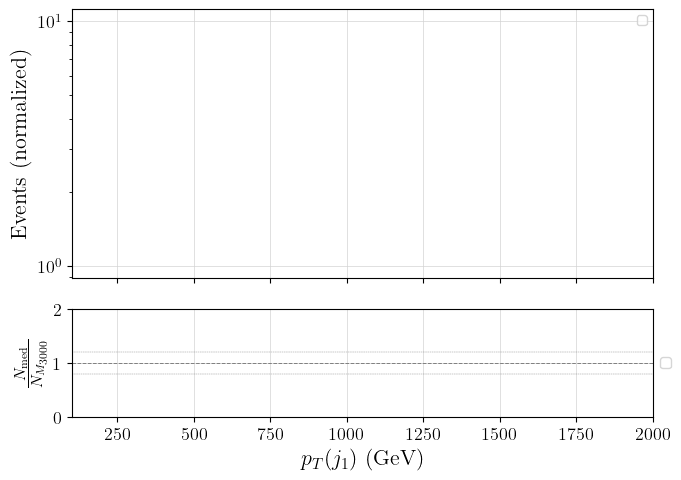

In [17]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(7,5))

mass = 3000.0


for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
#     if parameters[label]['mDM'] != 950.0: continue
    bin_ref, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50),weights=weights[label], density=True)
    bin_ref_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50),weights=weights[label], density=False)
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50),weights=weights[label]**2, density=False)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mDM'] != 1.0: continue
#     if parameters[label]['mDM'] == 250.0: continue
    if parameters[label]['mMed'] == 500.0: continue
    if parameters[label]['mMed'] == 2000.0: continue
    if parameters[label]['mMed'] == 5000.0: continue
    
    ax[0].hist(pTj1[label],bins=np.linspace(100,2000,50),
               label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    binc,binEdges = np.histogram(pTj1[label],bins=np.linspace(100,2000,50), weights=weights[label], density=True)
    binc_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50), weights=weights[label], density=False)
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2, density=False)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    ax[0].errorbar(binCenter, binc, yerr = errorc, marker = '.', drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mMed'] == mass: continue
    if parameters[label]['mMed'] == 1000.0: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratiok = k*binc_nodensity/bin_ref_nodensity
    ratio = binc/bin_ref
    ratioErr = np.sqrt(errorc**2 + ratiok**2 * err_ref**2)/bin_ref_nodensity
    
    
    
    ax[1].scatter(binCenter, ratiok, marker='.', s=30, color=colors[label],
                  label=r'$M_{med} = %1.0f$ GeV'%(parameters[label]['mMed']))
    ax[1].errorbar(binCenter,ratiok, yerr = ratioErr, fmt='.', color=colors[label])
    

    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'Events (normalized)')
plt.xlim(100,2000)
ax[0].legend(loc='upper right', fontsize='x-small')
ax[1].set_ylim(0.,2.)
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel(r'$\frac{N_{\rm med}}{N_{M_{3000}}}$')
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
 

plt.tight_layout()

# plt.savefig('./figures/DMsimp_S3D_uR_ptj1_no_onshell_1.png')
plt.show()

In [ ]:
errorc[0], ratiok[0], err_ref[0], bin_ref_nodensity[0]

In [ ]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(7,5))

mass = 1.0


for label in parameters.keys():
    if parameters[label]['mDM'] != mass: continue
#     if parameters[label]['mDM'] != 950.0: continue
    bin_ref, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50),weights=weights[label], density=True)
    bin_ref_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50),weights=weights[label], density=False)
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50),weights=weights[label]**2, density=False)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mMed'] != 4000.0: continue
#     if parameters[label]['mDM'] == 250.0: continue
#     if parameters[label]['mMed'] == 500.0: continue
#     if parameters[label]['mMed'] == 2000.0: continue
#     if parameters[label]['mMed'] == 5000.0: continue
    
    ax[0].hist(pTj1[label],bins=np.linspace(100,2000,50),
               label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
               histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    binc,binEdges = np.histogram(pTj1[label],bins=np.linspace(100,2000,50), weights=weights[label], density=True)
    binc_nodensity, _ = np.histogram(pTj1[label],bins=np.linspace(100,2000,50), weights=weights[label], density=False)
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2, density=False)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    ax[0].errorbar(binCenter, binc, yerr = errorc, marker = '.', drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mDM'] == mass: continue
#     if parameters[label]['mMed'] == 1000.0: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratiok = k*binc_nodensity/bin_ref_nodensity
    ratio = binc/bin_ref
    ratioErr = np.sqrt(errorc**2 + ratiok**2 * err_ref**2)/bin_ref_nodensity
    
    
    
    ax[1].scatter(binCenter, ratio, marker='.', s=30, color=colors[label],
                  label=r'$M_{med} = %1.0f$ GeV'%(parameters[label]['mMed']))
    ax[1].errorbar(binCenter,ratio, yerr = ratioErr, fmt='.', color=colors[label])
    

    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'Events (normalized)')
plt.xlim(100,2000)
ax[0].legend(loc='upper right', fontsize='x-small')
# ax[1].set_ylim(0.5,1.5)
ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel(r'$\frac{N_{1900}}{N_{M_{1}}}$')
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
# ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
# ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
 

plt.tight_layout()

# plt.savefig('./figures/DMsimp_S3D_uR_ptj1_no_onshell_1.png')
plt.show()

In [60]:
k

6.51595352495128

In [61]:
bin_ref/bin_ref_nodensity

array([2188.12652161, 2188.12652161, 2188.12652161, 2188.12652161,
       2188.12652161, 2188.12652161, 2188.12652161, 2188.12652161,
       2188.12652161, 2188.12652161, 2188.12652161, 2188.12652161,
       2188.12652161, 2188.12652161, 2188.12652161, 2188.12652161,
       2188.12652161, 2188.12652161, 2188.12652161, 2188.12652161,
       2188.12652161, 2188.12652161, 2188.12652161, 2188.12652161,
       2188.12652161, 2188.12652161, 2188.12652161, 2188.12652161,
       2188.12652161, 2188.12652161, 2188.12652161, 2188.12652161,
       2188.12652161, 2188.12652161, 2188.12652161, 2188.12652161,
       2188.12652161, 2188.12652161, 2188.12652161, 2188.12652161,
       2188.12652161, 2188.12652161, 2188.12652161, 2188.12652161,
       2188.12652161, 2188.12652161, 2188.12652161, 2188.12652161,
       2188.12652161])

In [62]:
binc/binc_nodensity

array([14257.79256942, 14257.79256942, 14257.79256942, 14257.79256942,
       14257.79256942, 14257.79256942, 14257.79256942, 14257.79256942,
       14257.79256942, 14257.79256942, 14257.79256942, 14257.79256942,
       14257.79256942, 14257.79256942, 14257.79256942, 14257.79256942,
       14257.79256942, 14257.79256942, 14257.79256942, 14257.79256942,
       14257.79256942, 14257.79256942, 14257.79256942, 14257.79256942,
       14257.79256942, 14257.79256942, 14257.79256942, 14257.79256942,
       14257.79256942, 14257.79256942, 14257.79256942, 14257.79256942,
       14257.79256942, 14257.79256942, 14257.79256942, 14257.79256942,
       14257.79256942, 14257.79256942, 14257.79256942, 14257.79256942,
       14257.79256942, 14257.79256942, 14257.79256942, 14257.79256942,
       14257.79256942, 14257.79256942, 14257.79256942, 14257.79256942,
       14257.79256942])

In [63]:
binc/bin_ref

array([1.11019762, 0.90039742, 0.90281552, 0.94148182, 1.01172107,
       0.98683092, 1.01518068, 1.08123721, 1.03689001, 1.08433867,
       1.0606609 , 1.06327164, 1.00304394, 1.07379698, 1.11527244,
       1.09640577, 1.13723518, 1.07163956, 1.04664287, 1.15054628,
       1.17269371, 1.14748353, 1.15154136, 1.14159265, 1.17757693,
       1.19025372, 1.10631349, 1.20278121, 1.23296141, 1.20247793,
       1.18455008, 1.17977734, 1.36970333, 1.27524365, 1.2524375 ,
       1.28631268, 1.27239191, 1.2420035 , 1.23948655, 1.46809608,
       1.24470689, 1.37455745, 1.22409584, 1.23439395, 1.57020484,
       1.29719162, 1.36355766, 0.91583457, 1.3132807 ])

In [64]:
ratiok

array([1.1101928 , 0.90039351, 0.9028116 , 0.94147773, 1.01171668,
       0.98682664, 1.01517628, 1.08123252, 1.03688552, 1.08433397,
       1.0606563 , 1.06326702, 1.00303959, 1.07379232, 1.11526761,
       1.09640102, 1.13723025, 1.07163492, 1.04663833, 1.15054128,
       1.17268862, 1.14747855, 1.15153637, 1.1415877 , 1.17757182,
       1.19024856, 1.10630869, 1.20277599, 1.23295607, 1.20247271,
       1.18454494, 1.17977222, 1.36969739, 1.27523812, 1.25243207,
       1.2863071 , 1.27238639, 1.24199811, 1.23948118, 1.46808971,
       1.24470149, 1.37455149, 1.22409053, 1.23438859, 1.57019803,
       1.29718599, 1.36355174, 0.9158306 , 1.313275  ])

In [48]:
bin_ref_nodensity

array([4.37366174e-06, 3.51378529e-06, 1.32777340e-06, 6.95680725e-07,
       4.13735845e-07, 2.47150256e-07, 1.65488660e-07, 1.13078936e-07,
       8.11639701e-08, 5.91761102e-08, 4.57139917e-08, 3.34135185e-08,
       2.66905240e-08, 2.02843961e-08, 1.57163985e-08, 1.24612999e-08,
       9.61826844e-09, 7.88692630e-09, 6.52890221e-09, 5.02969498e-09,
       4.13302267e-09, 3.34855486e-09, 2.61666198e-09, 2.25301808e-09,
       1.83572985e-09, 1.46046177e-09, 1.23915828e-09, 9.96001612e-10,
       8.01161712e-10, 7.01193550e-10, 6.02035071e-10, 4.88661705e-10,
       3.77651749e-10, 3.31370669e-10, 2.75489200e-10, 2.20651938e-10,
       1.91869622e-10, 1.68083646e-10, 1.36851042e-10, 1.03718536e-10,
       9.08004512e-11, 7.82682742e-11, 7.21230078e-11, 6.31867203e-11,
       4.08934401e-11, 4.00611447e-11, 3.17576112e-11, 3.04262288e-11,
       2.54031061e-11])

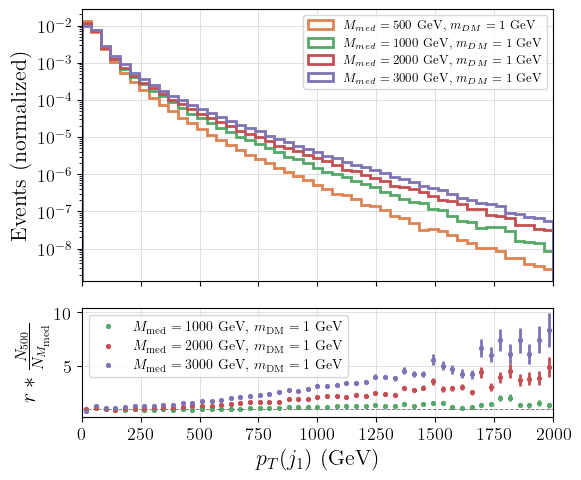

In [101]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(6,5))

mass = 500.0


for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
#     if parameters[label]['mDM'] != 950.0: continue
    pt_ref, _ = np.histogram(pTj1[label],bins=np.linspace(0,2000,50),weights=weights[label])
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(0,2000,50),weights=weights[label]**2)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mDM'] != 1.0: continue
    if parameters[label]['mMed'] == 100.0: continue
#     if parameters[label]['mDM'] == 750.0: continue
    
    ax[0].hist(pTj1[label],bins=np.linspace(0,2000,50),
                                   label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
                                         histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    binc,binEdges = np.histogram(pTj1[label],bins=np.linspace(0,2000,50), weights=weights[label])
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
#     ax[0].errorbar(binCenter,binc,yerr = errorc, marker = '.', 
#                  drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mMed'] == mass: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratio = k*binc/pt_ref
    ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref
    
    ax[1].scatter(binCenter, ratio, marker='.', s=30, color=colors[label],
                  label=r'$M_{\rm med} = %1.0f$ GeV, $m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratio, yerr = ratioErr, fmt='.', color=colors[label])
    

    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'Events (normalized)')
plt.xlim(0,2000)
ax[0].legend(loc='upper right', fontsize='x-small')
# ax[1].set_ylim(0.5,1.5)
ax[1].legend()
ax[1].set_ylabel(r'$r * \frac{N_{500}}{N_{M_{\rm med}}}$')
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
 

plt.tight_layout()

plt.savefig('./figures/DMsimp_S3D_uR_ptj1_no_onshell_1_v2.png')
plt.show()

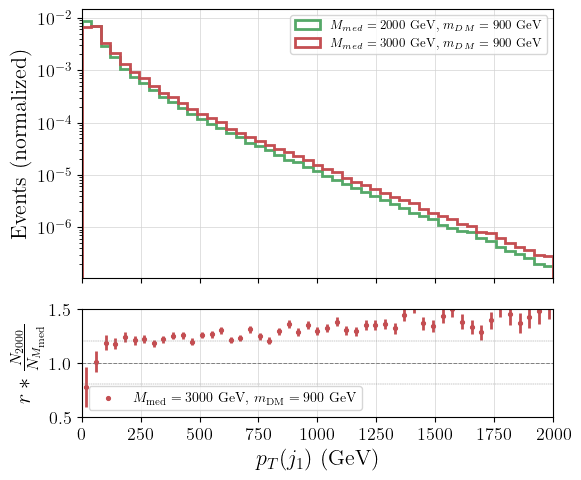

In [95]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(6,5))

mass = 2000.0


for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
#     if parameters[label]['mDM'] != 950.0: continue
    pt_ref, _ = np.histogram(pTj1[label],bins=np.linspace(0,2000,50),weights=weights[label])
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(0,2000,50),weights=weights[label]**2)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mDM'] != 900.0: continue
    if parameters[label]['mMed'] == 100.0: continue
#     if parameters[label]['mDM'] == 750.0: continue
    
    ax[0].hist(pTj1[label],bins=np.linspace(0,2000,50),
                                   label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
                                         histtype='step', weights=weights[label],linewidth=2, density=True, color=colors[label])
    binc,binEdges = np.histogram(pTj1[label],bins=np.linspace(0,2000,50), weights=weights[label])
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
#     ax[0].errorbar(binCenter,binc,yerr = errorc, marker = '.', 
#                  drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mMed'] == mass: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratio = k*binc/pt_ref
    ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref
    
    ax[1].scatter(binCenter, ratio, marker='.', s=30, color=colors[label],
                  label=r'$M_{\rm med} = %1.0f$ GeV, $m_{\rm DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratio, yerr = ratioErr, fmt='.', color=colors[label])
    

    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'Events (normalized)')
plt.xlim(0,2000)
ax[0].legend(loc='upper right', fontsize='x-small')
ax[1].set_ylim(0.5,1.5)
ax[1].legend()
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].set_ylabel(r'$r * \frac{N_{2000}}{N_{M_{\rm med}}}$')

plt.tight_layout()

plt.savefig('./figures/DMsimp_S3D_uR_ptj1_no_onshell_900.png')
plt.show()

In [38]:
parameters

{'run_01': {'mMed': 100.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_02': {'mMed': 500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_03': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_04': {'mMed': 2000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_05': {'mMed': 3000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_06': {'mMed': 500.0, 'mDM': 200.0, 'g': 0.25, 'Events': 50000},
 'run_07': {'mMed': 1000.0, 'mDM': 200.0, 'g': 0.25, 'Events': 50000},
 'run_08': {'mMed': 2000.0, 'mDM': 200.0, 'g': 0.25, 'Events': 50000},
 'run_09': {'mMed': 3000.0, 'mDM': 200.0, 'g': 0.25, 'Events': 50000},
 'run_10': {'mMed': 1000.0, 'mDM': 400.0, 'g': 0.25, 'Events': 50000},
 'run_11': {'mMed': 2000.0, 'mDM': 400.0, 'g': 0.25, 'Events': 50000},
 'run_12': {'mMed': 3000.0, 'mDM': 400.0, 'g': 0.25, 'Events': 50000},
 'run_13': {'mMed': 2000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000},
 'run_14': {'mMed': 3000.0, 'mDM': 900.0, 'g': 0.25, 'Events': 50000}}

In [37]:
totalweight

{'run_01': 0.22904674392047525,
 'run_02': 0.004317065723305439,
 'run_03': 0.0005019782879924701,
 'run_04': 5.563833003870651e-05,
 'run_05': 1.1196911350640074e-05,
 'run_06': 0.0013545486102423164,
 'run_07': 0.00020507032508049655,
 'run_08': 2.9248238067221442e-05,
 'run_09': 7.236047598802706e-06,
 'run_10': 9.51188381103729e-05,
 'run_11': 1.316332225297084e-05,
 'run_12': 3.9677676875246816e-06,
 'run_13': 2.2050420662778916e-06,
 'run_14': 5.973365402504444e-07}

/tmp/ipykernel_11918/1857687031.py:34: RuntimeWarning: divide by zero encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_11918/1857687031.py:34: RuntimeWarning: invalid value encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_11918/1857687031.py:35: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs


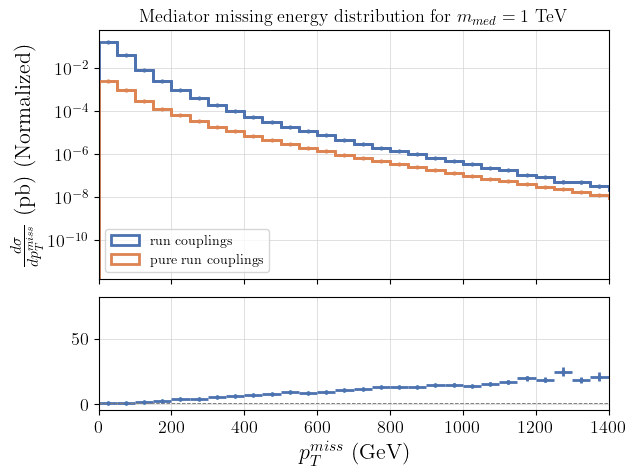

In [50]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(6,5))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

# k=1
# k = totalweight['pseudoscalar_run03']/totalweight['scalar_run03']
k = totalweight['run_01']/totalweight['run_02']

for label,metPts in met.items():
    if label in ['run_02']:
        bincSc,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'pure %s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2)
        binCenter = (binEdges[0:-1]+binEdges[1:])/2.
        errorSc2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorSc = np.sqrt(errorSc2)
        errorSc[errorSc<0] = 0
        ax[0].errorbar(binCenter,bincSc,yerr = errorSc, marker = '.', drawstyle = 'steps-mid',color=colors[label])

    
    if label in ['run_01']:
        bincPs,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2)
        errorPs2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        binCenter = (binEdges[0:-1]+binEdges[1:])/2.
        errorPs = np.sqrt(errorPs2)
        errorPs[errorPs<0] = 0
        
        ax[0].errorbar(binCenter,bincPs,yerr = errorPs, marker = '.', drawstyle = 'steps-mid',color=colors[label])

        
ratio = k*bincSc/bincPs
ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs
binCenter = (binEdges[0:-1]+binEdges[1:])/2.
errorh = (np.diff(binEdges+[2000.])/2).tolist()

ax[1].scatter(binCenter, ratio, marker='.')
ax[1].errorbar(binCenter,ratio, xerr = errorh, yerr = ratioErr, fmt='.', color=colors['run_01'])
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
# ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
# ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)

        
ax[0].set_yscale('log')
# ax[0].set_ylim(6e-8,2e-2)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)')
ax[0].set_xlim(0,1400)
ax[0].legend(loc='lower left')
ax[0].set_title(r'Mediator missing energy distribution for $m_{med} = 1$ TeV')


# ax[1].set_ylim(0.5,1.5)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)')

# plt.savefig('plot-s-ps-bias.png')
plt.show()

In [42]:
len(binCenter)

49

In [45]:
len(bincPs)

100

In [115]:
parameters

{'run_01': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_02': {'mMed': 2500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_03': {'mMed': 1000.0, 'mDM': 400.0, 'g': 0.25, 'Events': 50000},
 'run_04': {'mMed': 1000.0, 'mDM': 200.0, 'g': 0.25, 'Events': 50000},
 'run_05': {'mMed': 2500.0, 'mDM': 600.0, 'g': 0.25, 'Events': 50000},
 'run_06': {'mMed': 2500.0, 'mDM': 1200.0, 'g': 0.25, 'Events': 50000},
 'run_07': {'mMed': 500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_08': {'mMed': 500.0, 'mDM': 200.0, 'g': 0.25, 'Events': 50000},
 'run_09': {'mMed': 2000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_10': {'mMed': 2000.0, 'mDM': 250.0, 'g': 0.25, 'Events': 50000},
 'run_11': {'mMed': 2000.0, 'mDM': 500.0, 'g': 0.25, 'Events': 50000},
 'run_12': {'mMed': 2000.0, 'mDM': 750.0, 'g': 0.25, 'Events': 50000},
 'run_13': {'mMed': 2000.0, 'mDM': 950.0, 'g': 0.25, 'Events': 50000},
 'run_14': {'mMed': 250.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'run_15': {'mMed'

/tmp/ipykernel_45894/2886357679.py:31: RuntimeWarning: divide by zero encountered in divide
  ratio = k*binc/pt_ref
/tmp/ipykernel_45894/2886357679.py:31: RuntimeWarning: invalid value encountered in divide
  ratio = k*binc/pt_ref
/tmp/ipykernel_45894/2886357679.py:32: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref


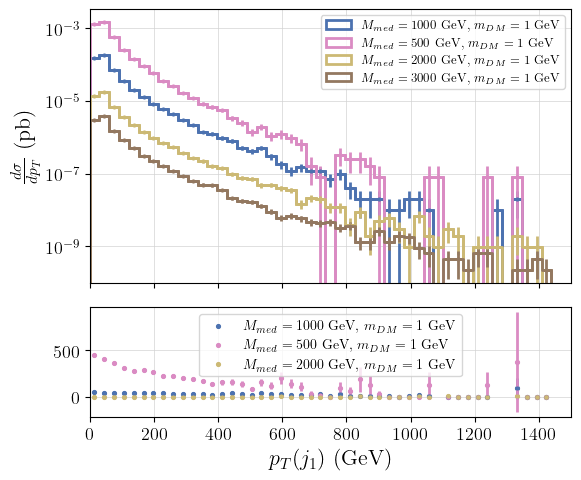

In [124]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(6,5))

mass = 1


for label in parameters.keys():
    if parameters[label]['mDM'] != mass: continue
    if parameters[label]['mMed'] != 3000.0: continue
    pt_ref, _ = np.histogram(pTj1[label],bins=np.linspace(0,1500,50),weights=weights[label])
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(0,1500,50),weights=weights[label]**2)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mDM'] != mass: continue
    if parameters[label]['mMed'] == 250.0: continue
    if parameters[label]['mMed'] == 2500.0: continue
    
    binc,binEdges,patches = ax[0].hist(pTj1[label],bins=np.linspace(0,1500,50),
                                   label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
                                         histtype='step', weights=weights[label],linewidth=2, density=False, color=colors[label])
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    ax[0].errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mMed'] == 3000.0: continue
#     k = weight_ref/totalweight[label]
    k = 1
    ratio = k*binc/pt_ref
    ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref
    
    ax[1].scatter(binCenter, ratio, marker='.', s=30, color=colors[label],
                  label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratio, yerr = ratioErr, fmt='.', color=colors[label])
    

    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,1500)
ax[0].legend(loc='upper right', fontsize='x-small')
# ax[1].set_ylim(0.5,1.5)
ax[1].legend()
 

plt.tight_layout()

plt.savefig('./figures/ptj1_no_onshell_mxd_1.png')
plt.show()

/tmp/ipykernel_45894/1945078493.py:31: RuntimeWarning: divide by zero encountered in divide
  ratio = k*binc/pt_ref
/tmp/ipykernel_45894/1945078493.py:32: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref


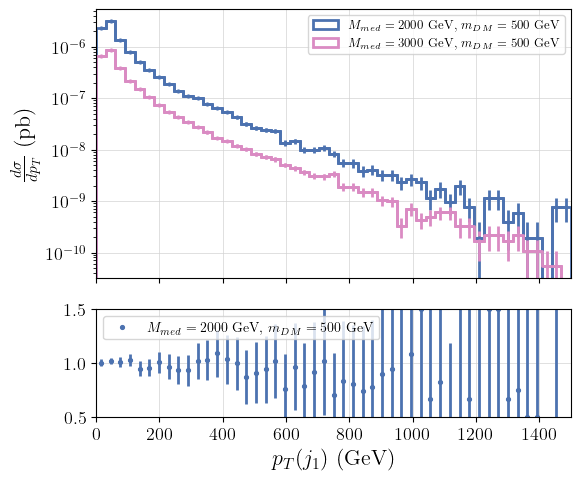

In [127]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(6,5))

mass = 500


for label in parameters.keys():
    if parameters[label]['mDM'] != mass: continue
    if parameters[label]['mMed'] != 3000.0: continue
    pt_ref, _ = np.histogram(pTj1[label],bins=np.linspace(0,1500,50),weights=weights[label])
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(0,1500,50),weights=weights[label]**2)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mDM'] != mass: continue
#     if parameters[label]['mMed'] == 250.0: continue
#     if parameters[label]['mMed'] == 2500.0: continue
    
    binc,binEdges,patches = ax[0].hist(pTj1[label],bins=np.linspace(0,1500,50),
                                   label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
                                         histtype='step', weights=weights[label],linewidth=2, density=False, color=colors[label])
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    ax[0].errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mMed'] == 3000.0: continue
    k = weight_ref/totalweight[label]
#     k = 1
    ratio = k*binc/pt_ref
    ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref
    
    ax[1].scatter(binCenter, ratio, marker='.', s=30, color=colors[label],
                  label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratio, yerr = ratioErr, fmt='.', color=colors[label])
    

    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,1500)
ax[0].legend(loc='upper right', fontsize='x-small')
ax[1].set_ylim(0.5,1.5)
ax[1].legend()
 

plt.tight_layout()

plt.savefig('./figures/ptj1_no_onshell_mxd_500.png')
plt.show()

/tmp/ipykernel_45894/687533758.py:31: RuntimeWarning: divide by zero encountered in divide
  ratio = k*binc/pt_ref
/tmp/ipykernel_45894/687533758.py:31: RuntimeWarning: invalid value encountered in divide
  ratio = k*binc/pt_ref
/tmp/ipykernel_45894/687533758.py:32: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref


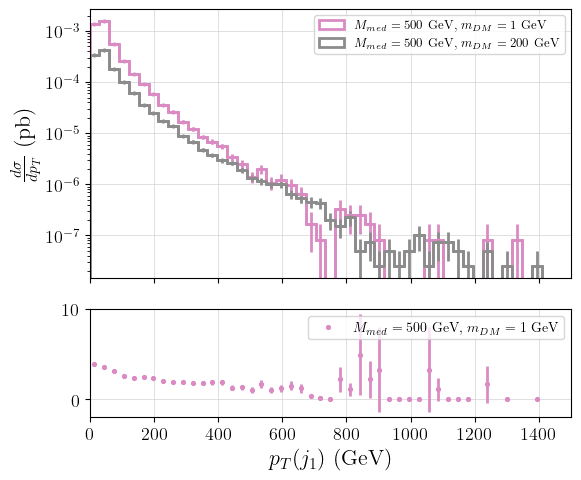

In [121]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.5, 1]},figsize=(6,5))

mass = 500


for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
    if parameters[label]['mDM'] != 200.0: continue
    pt_ref, _ = np.histogram(pTj1[label],bins=np.linspace(0,1500,50),weights=weights[label])
    err_ref2, _ = np.histogram(pTj1[label],bins=np.linspace(0,1500,50),weights=weights[label]**2)
    err_ref = np.sqrt(err_ref2)
    weight_ref = totalweight[label]

for label in parameters.keys():
    if parameters[label]['mMed'] != mass: continue
    if parameters[label]['mDM'] == 250.0: continue
    if parameters[label]['mDM'] == 750.0: continue
    
    binc,binEdges,patches = ax[0].hist(pTj1[label],bins=np.linspace(0,1500,50),
                                   label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']),
                                         histtype='step', weights=weights[label],linewidth=2, density=False, color=colors[label])
    errorc2,_ = np.histogram(pTj1[label],bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    ax[0].errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])
    
    if parameters[label]['mDM'] == 200.0: continue
#     k = weight_ref/totalweight[label]
    k = 1
    ratio = k*binc/pt_ref
    ratioErr = np.sqrt(errorc**2 + ratio**2 * err_ref**2)/pt_ref
    
    ax[1].scatter(binCenter, ratio, marker='.', s=30, color=colors[label],
                  label=r'$M_{med} = %1.0f$ GeV, $m_{DM} = %1.0f$ GeV'%(parameters[label]['mMed'], parameters[label]['mDM']))
    ax[1].errorbar(binCenter,ratio, yerr = ratioErr, fmt='.', color=colors[label])
    

    
ax[0].set_yscale('log')
# plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
ax[0].set_ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,1500)
ax[0].legend(loc='upper right', fontsize='x-small')
# ax[1].set_ylim(0.5,1.5)
ax[1].legend()
 

plt.tight_layout()

plt.savefig('./figures/ptj1_no_onshell_500.png')
plt.show()

In [92]:
pt_ref

array([4.36293696e-07, 5.90510571e-07, 2.68378916e-07, 1.62258622e-07,
       1.06312680e-07, 7.11059839e-08, 5.57920328e-08, 4.23634677e-08,
       3.31674016e-08, 2.40482900e-08, 2.06622908e-08, 1.75456324e-08,
       1.42750649e-08, 1.07351567e-08, 9.96561138e-09, 8.81129346e-09,
       7.15677110e-09, 6.38722582e-09, 5.30986243e-09, 4.50183989e-09,
       3.42447650e-09, 3.46295376e-09, 2.65493122e-09, 2.69340848e-09,
       1.80843141e-09, 1.88538594e-09, 1.65452235e-09, 1.65452235e-09,
       9.23454336e-10, 1.11584066e-09, 8.46499808e-10, 6.15636224e-10,
       7.31068016e-10, 6.54113488e-10, 5.00204432e-10, 4.61727168e-10,
       2.30863584e-10, 4.23249904e-10, 3.07818112e-10, 2.30863584e-10,
       2.30863584e-10, 1.53909056e-10, 2.30863584e-10, 2.30863584e-10,
       7.69545280e-11, 3.84772640e-11, 2.30863584e-10, 7.69545280e-11,
       7.69545280e-11])

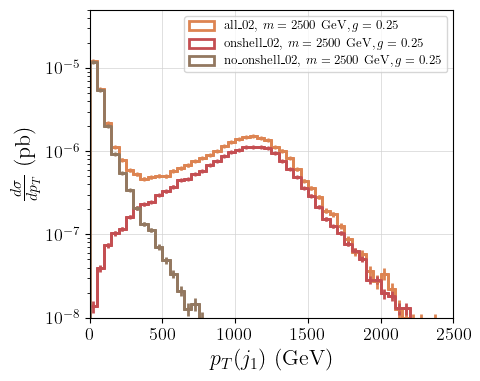

In [36]:
fig = plt.figure()
for label,pt in pTj1.items():
    if '01' in label: continue
    binc,binEdges,patches = plt.hist(pt,bins=np.linspace(0,5000,101),
                               label=r'%s, $m = %1.0f$ GeV$, g = %1.2f$'%(label, parameters[label]['mMed'], parameters[label]['g']),
                                     histtype='step',color=colors[label], weights=weights[label],linewidth=2, density=False)
    errorc2,_ = np.histogram(pt,bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])

    
plt.yscale('log')
plt.ylim(1e-8,5e-5)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
plt.ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,2500)
plt.legend(loc='upper right', fontsize='x-small')
plt.tight_layout()

plt.savefig('ptj_02.png')
plt.show()

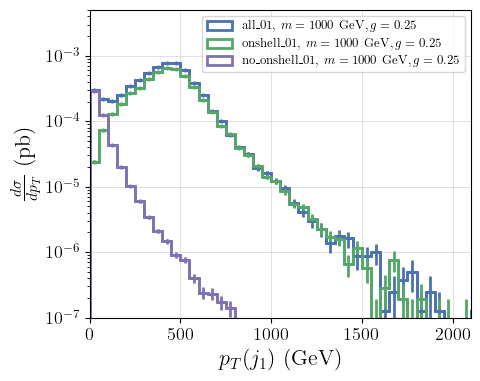

In [35]:
fig = plt.figure()
for label,pt in pTj1.items():
    if '02' in label: continue
    binc,binEdges,patches = plt.hist(pt,bins=np.linspace(0,5000,101),
                               label=r'%s, $m = %1.0f$ GeV$, g = %1.2f$'%(label, parameters[label]['mMed'], parameters[label]['g']),
                                     histtype='step',color=colors[label], weights=weights[label],linewidth=2, density=False)
    errorc2,_ = np.histogram(pt,bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])

    
plt.yscale('log')
plt.ylim(1e-7,5e-3)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
plt.ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,2100)
plt.legend(loc='upper right', fontsize='x-small')
plt.tight_layout()

plt.savefig('ptj_01.png')
plt.show()

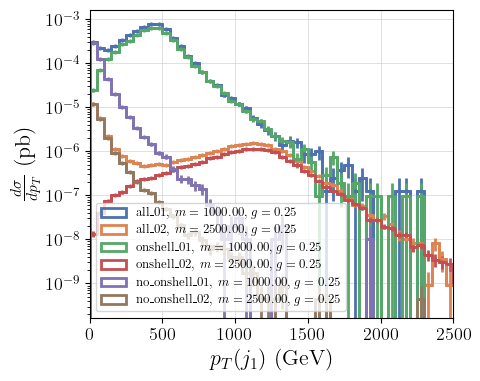

In [20]:
fig = plt.figure()
for label,pt in pTj1.items():
#     if label in ['scalar_run03']:
    binc,binEdges,patches = plt.hist(pt,bins=np.linspace(0,5000,101),
                               label=r'%s, $m = %1.0f$ GeV$, g = %1.2f$'%(label, parameters[label]['mMed'], parameters[label]['g']),
                                     histtype='step',color=colors[label], weights=weights[label],linewidth=2, density=False)
    errorc2,_ = np.histogram(pt,bins=binEdges,weights=weights[label]**2)
    errorc = np.sqrt(errorc2)
    binCenter = (binEdges[0:-1]+binEdges[1:])/2.
    plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
                 drawstyle = 'steps-mid',color=colors[label])

    
plt.yscale('log')
# plt.ylim(1e-9,1e-3)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
plt.ylabel(r'$\frac{d\sigma}{dp_{T}}$ (pb)')
plt.xlim(0,2500)
plt.legend(loc='lower left', fontsize='x-small')
plt.tight_layout()

plt.show()

In [16]:
parameters

{'all_01': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'all_02': {'mMed': 2500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'onshell_01': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'onshell_02': {'mMed': 2500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'no_onshell_01': {'mMed': 1000.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000},
 'no_onshell_02': {'mMed': 2500.0, 'mDM': 1.0, 'g': 0.25, 'Events': 50000}}

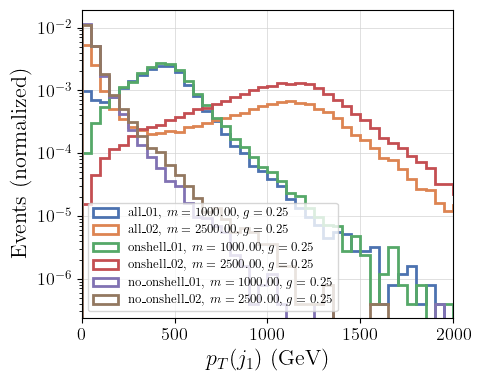

In [17]:
fig = plt.figure()
for label,pt in pTj1.items():
    binc,binEdges,patches = plt.hist(pt,bins=np.linspace(0,5000,101),
                               label=r'%s, $m = %1.2f, g = %1.2f$'%(label, parameters[label]['mMed'], parameters[label]['g']),
                                     histtype='step',color=colors[label], linewidth=2, density=True)

    
plt.yscale('log')
# plt.ylim(1e-9,1e-3)
plt.xlabel(r'$p_T(j_1)$ (GeV)')
plt.ylabel(r'Events (normalized)')
plt.xlim(0,2000)
plt.legend(loc='lower left', fontsize='x-small')
plt.tight_layout()
# plt.savefig('./figs_tchannel/plot_PTj_normalized_v2.png')

plt.show()

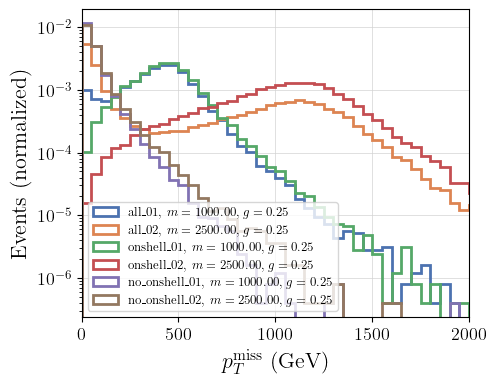

In [18]:
fig = plt.figure()
for label,pt in met.items():
    binc,binEdges,patches = plt.hist(pt,bins=np.linspace(0,5000,101),
                               label=r'%s, $m = %1.2f, g = %1.2f$'%(label, parameters[label]['mMed'], parameters[label]['g']),histtype='step',color=colors[label],
                               linewidth=2, density=True)
#     errorc2,_ = np.histogram(pt,bins=binEdges,weights=weights[label]**2)
#     errorc = np.sqrt(errorc2)
#     binCenter = (binEdges[0:-1]+binEdges[1:])/2.
#     plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
#                  drawstyle = 'steps-mid',color=colors[label])

    
plt.yscale('log')
# plt.ylim(1e-9,1e-3)
plt.xlabel(r'$p_T^{\rm miss}$ (GeV)')
plt.ylabel(r'Events (normalized)')
plt.xlim(0,2000)
plt.legend(loc='lower left', fontsize='x-small')
plt.tight_layout

plt.show()

In [14]:
# fig = plt.figure(figsize=(10,6))
# for label,metPts in met.items():
#     if 'run01' in label:
#         binc,binEdges,patches = plt.hist(metPts,bins=np.linspace(0,5000,101),
#                                         label=r'%s; $m_{DM} $= %1.f GeV' %(label.split('_')[0], parameters[label]['mDM']),
#                                          histtype='step',color=colors[label],
#                                          weights=weights[label],linewidth=2, density=True)
#         errorc2,_ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
#         errorc = np.sqrt(errorc2)
#         binCenter = (binEdges[0:-1]+binEdges[1:])/2.
# #         plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
# #                      drawstyle = 'steps-mid',color=colors[label])
#     if 'run02' in label:
#         binc,binEdges,patches = plt.hist(metPts,bins=np.linspace(0,5000,101),
#                                          label=r'%s; $m_{DM} $= %1.f GeV' %(label.split('_')[0], parameters[label]['mDM']),
#                                          histtype='step',color=colors[label],
#                                          weights=weights[label],linewidth=2, density=True)
#         errorc2,_ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
#         errorc = np.sqrt(errorc2)
#         binCenter = (binEdges[0:-1]+binEdges[1:])/2.

    
# plt.yscale('log')
# # plt.ylim(1e-8,1)
# plt.xlabel(r'$p_T^{miss}$ (GeV)')
# plt.ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb)')
# plt.xlim(0,1500)
# plt.legend(loc='lower left', fontsize='xx-small')
# plt.title(r'Missing energy distribution for $m_{med} = 500$ GeV')
# plt.show()

In [15]:
# fig = plt.figure(figsize=(10,6))
# for label,metPts in met.items():
#     if 'run04' in label:
#         binc,binEdges,patches = plt.hist(metPts,bins=np.linspace(0,5000,101),
#                                    label=label,histtype='step',color=colors[label],
#                                    weights=weights[label],linewidth=2,density=True)
# #         errorc2,_ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
# #         errorc = np.sqrt(errorc2)
# #         binCenter = (binEdges[0:-1]+binEdges[1:])/2.
# #         plt.errorbar(binCenter,binc,yerr = errorc, marker = '.', 
# #                      drawstyle = 'steps-mid',color=colors[label])

    
# plt.yscale('log')
# # plt.ylim(1e-3,1)
# plt.xlabel(r'$p_T^{miss}$ (GeV)')
# plt.ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb)')
# plt.xlim(0,2000)
# plt.legend(loc='upper right', fontsize='x-small')
# plt.show()

/tmp/ipykernel_66296/3762056230.py:32: RuntimeWarning: divide by zero encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_66296/3762056230.py:32: RuntimeWarning: invalid value encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_66296/3762056230.py:33: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs


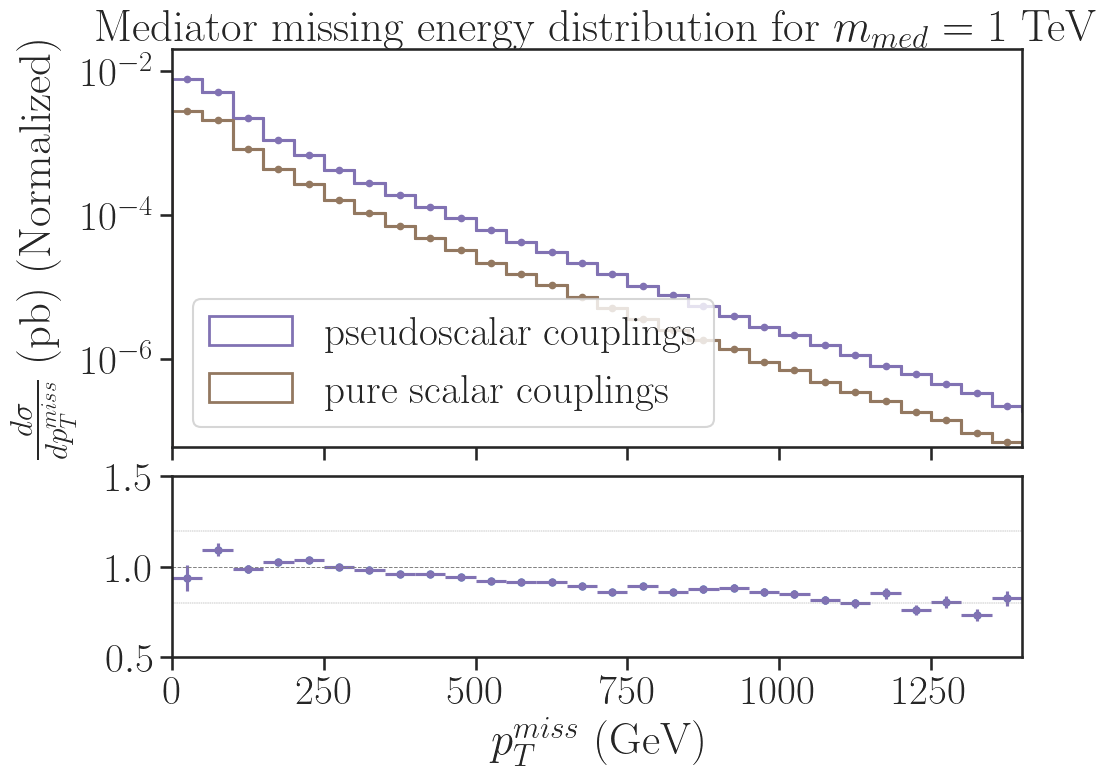

In [16]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

# k=1
k = totalweight['pseudoscalar_run03']/totalweight['scalar_run03']

for label,metPts in met.items():
    if label in ['scalar_run03']:
        bincSc,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'pure %s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2)
        binCenter = (binEdges[0:-1]+binEdges[1:])/2.
        errorSc2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorSc = np.sqrt(errorSc2)
        errorSc[errorSc<0] = 0
        ax[0].errorbar(binCenter,bincSc,yerr = errorSc, marker = '.', drawstyle = 'steps-mid',color=colors[label])

    
    if label in ['pseudoscalar_run03']:
        bincPs,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2)
        errorPs2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorPs = np.sqrt(errorPs2)
        errorPs[errorPs<0] = 0
        
        ax[0].errorbar(binCenter,bincPs,yerr = errorPs, marker = '.', drawstyle = 'steps-mid',color=colors[label])

        
ratio = k*bincSc/bincPs
ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs
binCenter = (binEdges[0:-1]+binEdges[1:])/2.
errorh = (np.diff(binEdges+[2000.])/2).tolist()

ax[1].scatter(binCenter, ratio, marker='.')
ax[1].errorbar(binCenter,ratio,xerr = errorh, yerr = ratioErr, fmt='.', color=colors['pseudoscalar_run03'])
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)

        
ax[0].set_yscale('log')
ax[0].set_ylim(6e-8,2e-2)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)')
ax[0].set_xlim(0,1400)
ax[0].legend(loc='lower left')
ax[0].set_title(r'Mediator missing energy distribution for $m_{med} = 1$ TeV')


ax[1].set_ylim(0.5,1.5)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)')

# plt.savefig('plot-s-ps-bias.png')
plt.show()

/tmp/ipykernel_66296/3705865879.py:28: RuntimeWarning: divide by zero encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_66296/3705865879.py:28: RuntimeWarning: invalid value encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_66296/3705865879.py:29: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


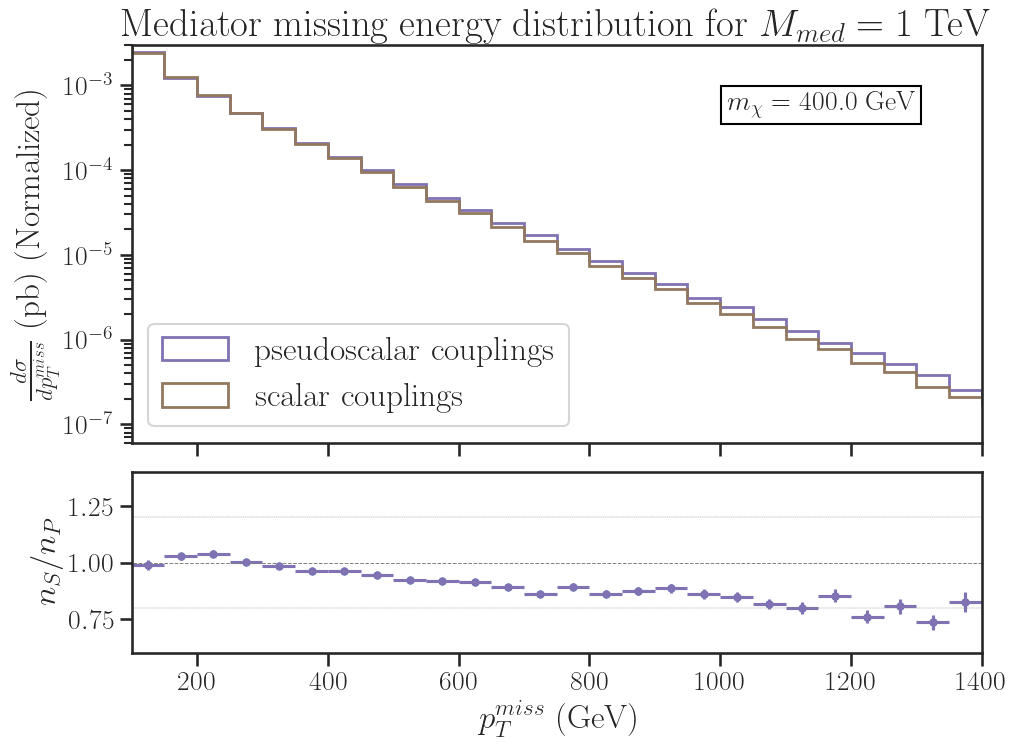

In [17]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

k = totalweight['pseudoscalar_run03']/totalweight['scalar_run03']

for label,metPts in met.items():
    if label in ['scalar_run03']:
        bincScNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2, density=True)
        bincSc, _ = np.histogram(metPts,bins=binEdges,weights=weights[label])
        errorSc2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorSc = np.sqrt(errorSc2)

    
    if label in ['pseudoscalar_run03']:
        bincPsNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2, density=True)
        bincPs, _ = np.histogram(metPts,bins=binEdges,weights=weights[label])
        errorPs2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorPs = np.sqrt(errorPs2)

        

ratio = k*bincSc/bincPs
ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs
errorh = (np.diff(binEdges+[2000.])/2).tolist()

ax[1].scatter(binCenter, ratio, marker='.')
ax[1].errorbar(binCenter,ratio,xerr = errorh, yerr = ratioErr, fmt='.', color=colors['pseudoscalar_run03'])
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)

        
ax[0].set_yscale('log')
ax[0].set_ylim(6e-8,3e-3)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)', fontsize=24)
ax[0].set_xlim(100,1400)
ax[0].legend(loc='lower left', fontsize=24)
ax[0].set_title(r'Mediator missing energy distribution for $M_{med} = 1$ TeV', fontsize=28)

ax[0].text(0.7,3,r'$m_{\chi} =$ %.1f GeV' %parameters['scalar_run03']['mDM'],
           fontsize=20,bbox=dict(facecolor='none', edgecolor='black'),transform = plt.gca().transAxes)

ax[0].tick_params(labelsize=20)
ax[1].tick_params(labelsize=20)


ax[1].set_xlim(100,1400)
ax[1].set_ylim(.6,1.4)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)', fontsize=24)
ax[1].set_ylabel(r'$n_{S}/n_{P}$', fontsize=24)


plt.savefig('plot-s-ps-bias-mdm400.eps', format='eps')
plt.show()

/tmp/ipykernel_66296/1482585364.py:27: RuntimeWarning: divide by zero encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_66296/1482585364.py:27: RuntimeWarning: invalid value encountered in divide
  ratio = k*bincSc/bincPs
/tmp/ipykernel_66296/1482585364.py:28: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs


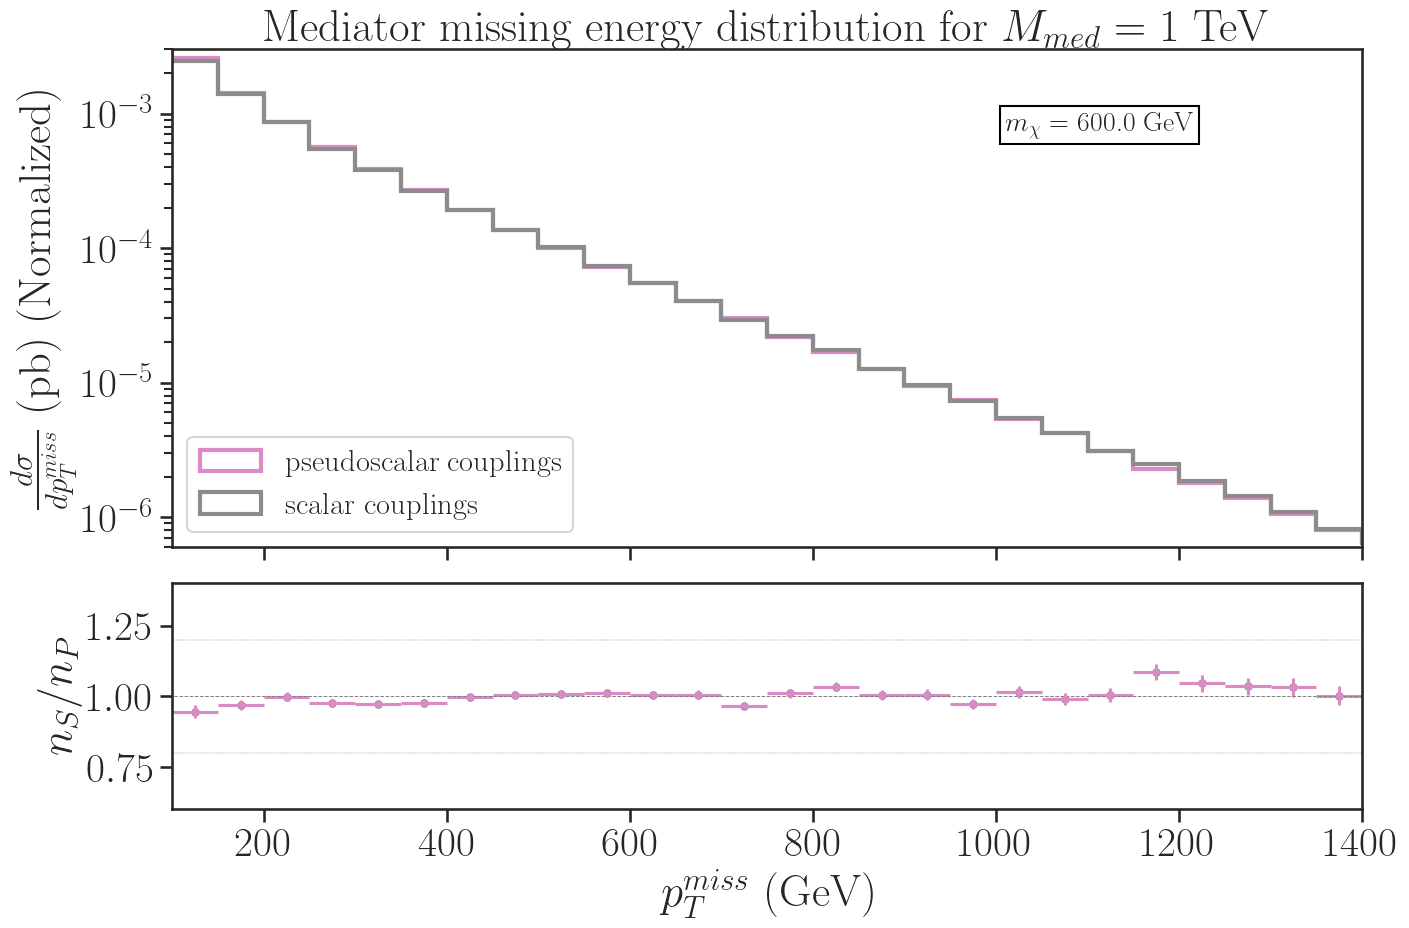

In [36]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(14,10))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

k = totalweight['pseudoscalar_run04']/totalweight['scalar_run04']

for label,metPts in met.items():
    if label in ['scalar_run04']:
        bincScNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=3, density=True)
        bincSc, _ = np.histogram(metPts,bins=binEdges,weights=weights[label])
        errorSc2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorSc = np.sqrt(errorSc2)

    
    if label in ['pseudoscalar_run04']:
        bincPsNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=3, density=True)
        bincPs, _ = np.histogram(metPts,bins=binEdges,weights=weights[label])
        errorPs2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorPs = np.sqrt(errorPs2)

        
ratio = k*bincSc/bincPs
ratioErr = np.sqrt(errorSc**2 + ratio**2 * errorPs**2)/bincPs
binCenter = (binEdges[0:-1]+binEdges[1:])/2.
errorh = (np.diff(binEdges+[2000.])/2).tolist()

ax[1].scatter(binCenter, ratio, marker='.')
ax[1].errorbar(binCenter,ratio,xerr=errorh, yerr=ratioErr, fmt='.', color=colors['pseudoscalar_run04'])
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)


ax[0].set_yscale('log')
ax[0].set_ylim(6e-7,3e-3)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)')
ax[0].set_xlim(100,1400)
ax[0].legend(loc='lower left', fontsize=22)
ax[0].set_title(r'Mediator missing energy distribution for $M_{med} = 1$ TeV')

ax[0].text(0.7,3,r'$m_{\chi} =$ %.1f GeV' %parameters['scalar_run04']['mDM'],
           fontsize=20,bbox=dict(facecolor='none', edgecolor='black'),transform = plt.gca().transAxes)

ax[0].tick_params()
ax[1].tick_params()


ax[1].set_xlim(100,1400)
ax[1].set_ylim(.6,1.4)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)')
ax[1].set_ylabel(r'$n_{S}/n_{P}$')


plt.savefig('plot-s-ps-bias-mdm600.png', dpi=600)
plt.show()

/tmp/ipykernel_66296/2192451492.py:28: RuntimeWarning: divide by zero encountered in divide
  ratio = k*bincAx/bincVec
/tmp/ipykernel_66296/2192451492.py:28: RuntimeWarning: invalid value encountered in divide
  ratio = k*bincAx/bincVec
/tmp/ipykernel_66296/2192451492.py:29: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorAx**2 + ratio**2 * errorVec**2)/bincVec


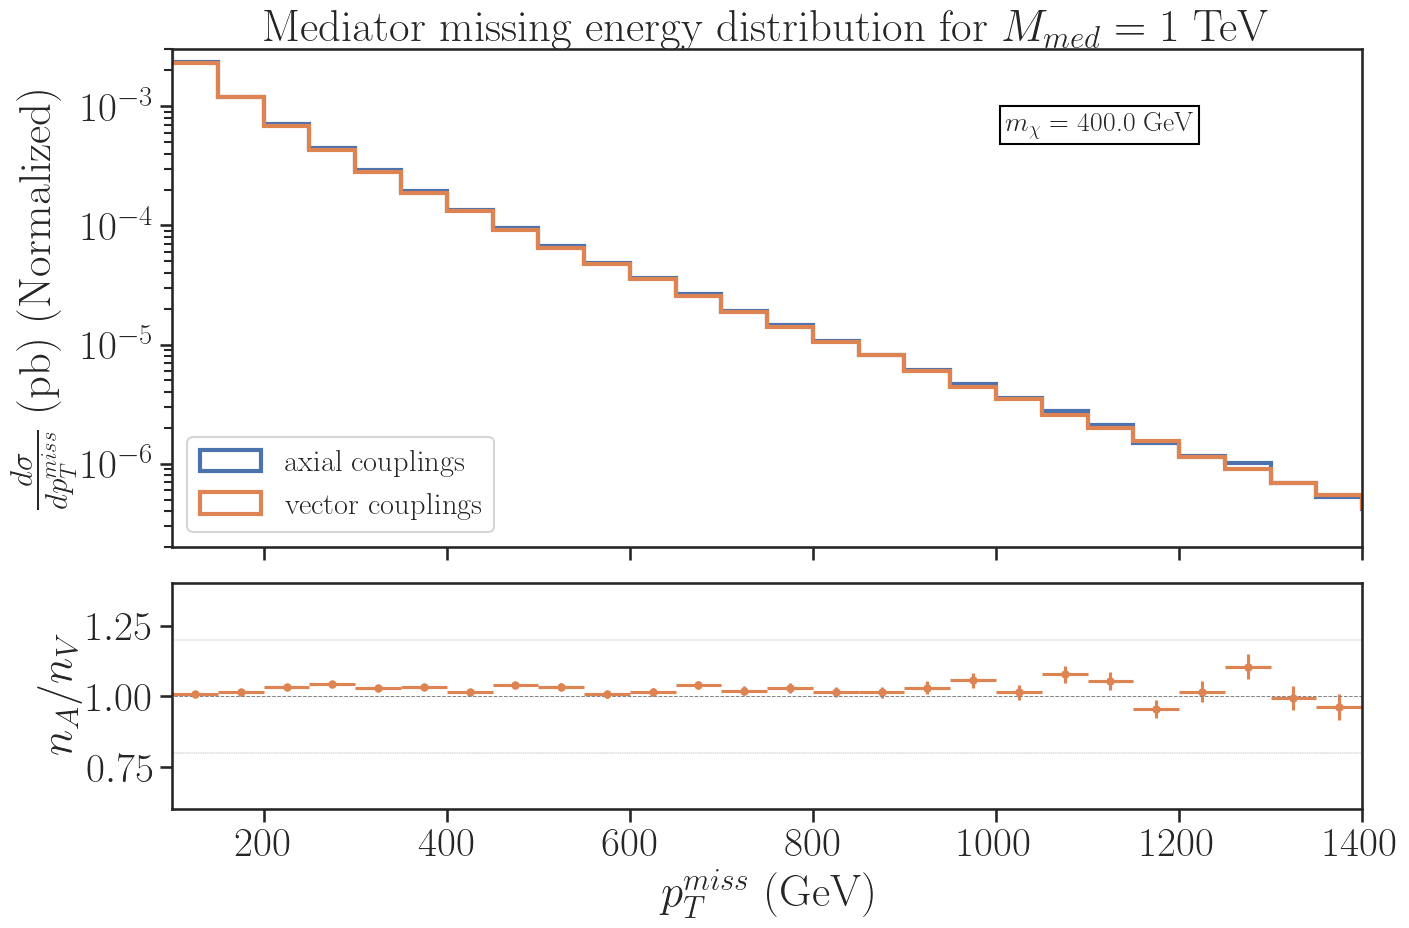

In [34]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(14,10))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

k = totalweight['vector_run03']/totalweight['axial_run03']

for label,metPts in met.items():
    if label in ['axial_run03']:
        bincAxNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=3, density=True)
        
        bincAx, _ = np.histogram(metPts,bins=binEdges,weights=weights[label], density=False)
        errorAx2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2, density=False)
        errorAx = np.sqrt(errorAx2)
        
    elif label in ['vector_run03']:
        bincVecNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=3, density=True)
        
        bincVec, _ = np.histogram(metPts,bins=binEdges,weights=weights[label], density=False)
        errorVec2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2, density=False)
        errorVec = np.sqrt(errorVec2)
        
        
ratio = k*bincAx/bincVec
ratioErr = np.sqrt(errorAx**2 + ratio**2 * errorVec**2)/bincVec

binCenter = (binEdges[0:-1]+binEdges[1:])/2.
errorh = (np.diff(binEdges+[2000.])/2).tolist()    

ax[1].scatter(binCenter, ratio, marker='.', color=colors['vector_run03'])
ax[1].errorbar(binCenter,ratio, xerr = errorh, yerr=ratioErr, fmt='.', color=colors['vector_run03'])
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
        

ax[0].set_yscale('log')
ax[0].set_ylim(2e-7,3e-3)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)')
ax[0].set_xlim(100,1400)
ax[0].legend(loc='lower left', fontsize=22)
ax[0].set_title(r'Mediator missing energy distribution for $M_{med} = 1$ TeV')

ax[0].text(0.7,3,r'$m_{\chi} =$ %.1f GeV' %parameters['axial_run03']['mDM'],
           fontsize=20,bbox=dict(facecolor='none', edgecolor='black'),transform = plt.gca().transAxes)

ax[0].tick_params()
ax[1].tick_params()

ax[1].set_xlim(100,1400)
ax[1].set_ylim(.6,1.4)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)')
ax[1].set_ylabel(r'$n_{A}/n_{V}$')

plt.savefig('plot-v-av-mxd400.png', dpi=600)
plt.show()

/tmp/ipykernel_66296/4252788444.py:28: RuntimeWarning: divide by zero encountered in divide
  ratio = k*bincAx/bincVec
/tmp/ipykernel_66296/4252788444.py:28: RuntimeWarning: invalid value encountered in divide
  ratio = k*bincAx/bincVec
/tmp/ipykernel_66296/4252788444.py:29: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorAx**2 + ratio**2 * errorVec**2)/bincVec
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


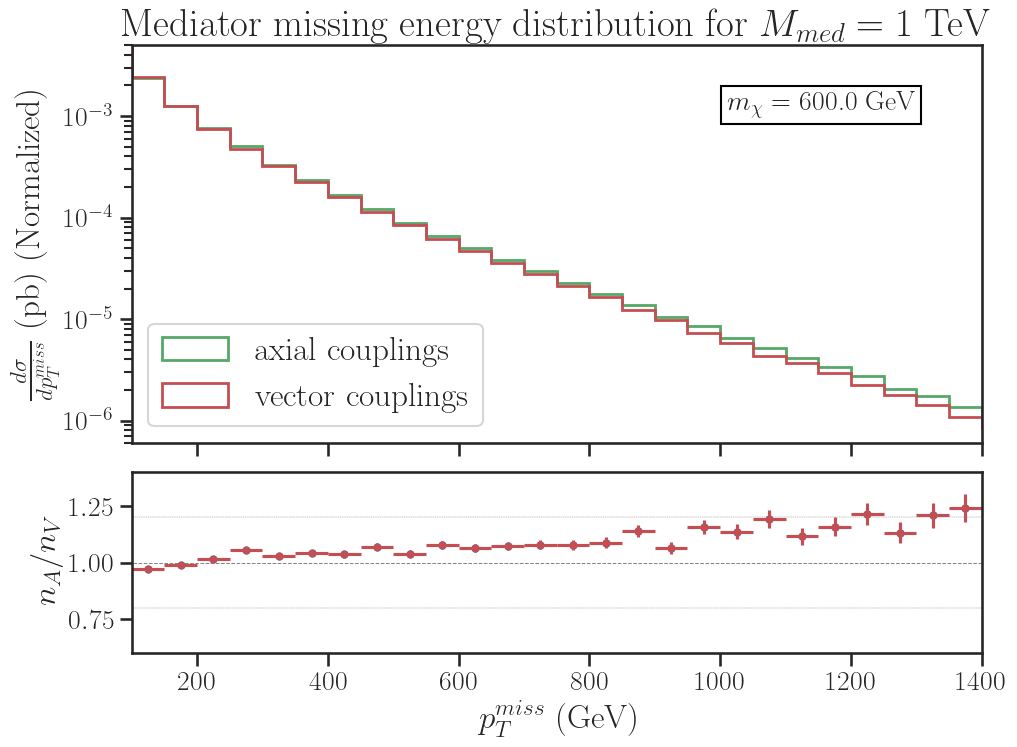

In [20]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

k = totalweight['vector_run04']/totalweight['axial_run04']


for label,metPts in met.items():
    if label in ['axial_run04']:
        bincAxNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2, density=True)
        bincAx, _ = np.histogram(metPts,bins=binEdges,weights=weights[label])
        errorAx2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorAx = np.sqrt(errorAx2)
        
    elif label in ['vector_run04']:
        bincVecNorm,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2, density=True)
        bincVec, _ = np.histogram(metPts,bins=binEdges,weights=weights[label])
        errorVec2, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        errorVec = np.sqrt(errorVec2)
    
        
        
ratio = k*bincAx/bincVec
ratioErr = np.sqrt(errorAx**2 + ratio**2 * errorVec**2)/bincVec
binCenter = (binEdges[0:-1]+binEdges[1:])/2.
errorh = (np.diff(binEdges+[2000.])/2).tolist()    

ax[1].scatter(binCenter, ratio, marker='.')
ax[1].errorbar(binCenter,ratio, xerr = errorh, yerr=ratioErr, fmt='.', color=colors['vector_run04'])
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
        

ax[0].set_yscale('log')
ax[0].set_ylim(6e-7,5e-3)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)', fontsize=24)
ax[0].set_xlim(100,1400)
ax[0].legend(loc='lower left', fontsize=24)
ax[0].set_title(r'Mediator missing energy distribution for $M_{med} = 1$ TeV', fontsize=28)

ax[0].text(0.7,3,r'$m_{\chi} =$ %.1f GeV' %parameters['axial_run04']['mDM'],
           fontsize=20,bbox=dict(facecolor='none', edgecolor='black'),transform = plt.gca().transAxes)

ax[0].tick_params(labelsize=20)
ax[1].tick_params(labelsize=20)

ax[1].set_xlim(100,1400)
ax[1].set_ylim(.6,1.4)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)', fontsize=24)
ax[1].set_ylabel(r'$n_{A}/n_{V}$', fontsize=24)


plt.savefig('plot-v-av-mxd600.eps', format='eps')
plt.show()

/tmp/ipykernel_66296/2434960696.py:23: RuntimeWarning: divide by zero encountered in divide
  ratio = bincS1/binc
/tmp/ipykernel_66296/2434960696.py:23: RuntimeWarning: invalid value encountered in divide
  ratio = bincS1/binc
/tmp/ipykernel_66296/2434960696.py:24: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorS1**2 + ratio**2 * errorL**2)/binc
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


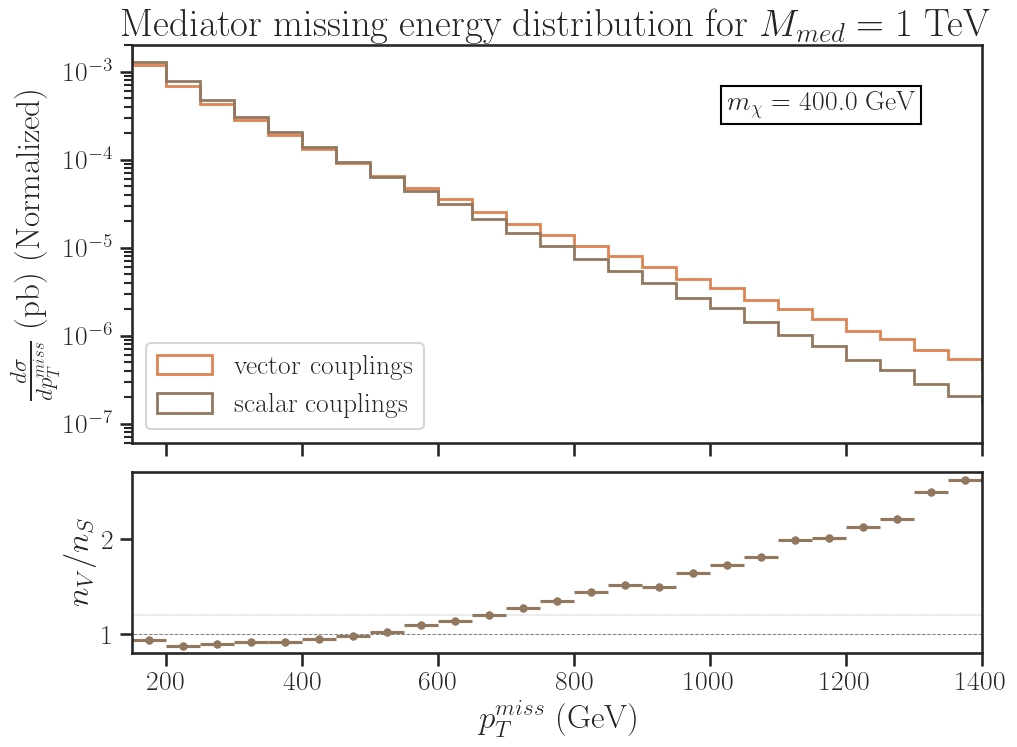

In [21]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(10,8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

for label,metPts in met.items():
    if label in ['vector_run03']:
        bincS1,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2, density=True)
        errorS1, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        
for label,metPts in met.items():
    if label in ['scalar_run03']:
        binc,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=2, density=True)
        
        binCenter = (binEdges[0:-1]+binEdges[1:])/2.
        errorh = (np.diff(binEdges+[2000.])/2).tolist()
        errorL, _ =  np.histogram(metPts,bins=binEdges,weights=weights[label]**2) 
        
        ratio = bincS1/binc
        ratioErr = np.sqrt(errorS1**2 + ratio**2 * errorL**2)/binc

        ax[1].scatter(binCenter, ratio, marker='.', label=r'%s couplings' %(label.split('_')[0]),
                      color=colors[label])
        ax[1].errorbar(binCenter,ratio, xerr=errorh, yerr=ratioErr, fmt='.', color=colors[label])
        
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
  
ax[0].text(0.7,3,r'$m_{\chi} =$ %.1f GeV' %parameters['scalar_run03']['mDM'],
           fontsize=20,bbox=dict(facecolor='none', edgecolor='black'),transform = plt.gca().transAxes)
ax[0].set_yscale('log')
ax[0].set_ylim(6e-8,2e-3)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)', fontsize=24)
ax[0].set_xlim(150,1400)
ax[0].legend(loc='lower left', fontsize=20)
ax[0].set_title(r'Mediator missing energy distribution for $M_{med} = 1$ TeV', fontsize=28)
ax[0].tick_params(labelsize=20)


ax[1].tick_params(labelsize=20)
ax[1].set_ylim(0.8,2.7)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)', fontsize=24)
ax[1].set_ylabel(r'$n_{V}/n_{S}$', fontsize=24)

plt.savefig('plot-s-ps-v-av-mxd400.eps', format='eps')
plt.show()

/tmp/ipykernel_66296/2430933865.py:23: RuntimeWarning: divide by zero encountered in divide
  ratio = bincS1/binc
/tmp/ipykernel_66296/2430933865.py:23: RuntimeWarning: invalid value encountered in divide
  ratio = bincS1/binc
/tmp/ipykernel_66296/2430933865.py:24: RuntimeWarning: invalid value encountered in multiply
  ratioErr = np.sqrt(errorS1**2 + ratio**2 * errorL**2)/binc


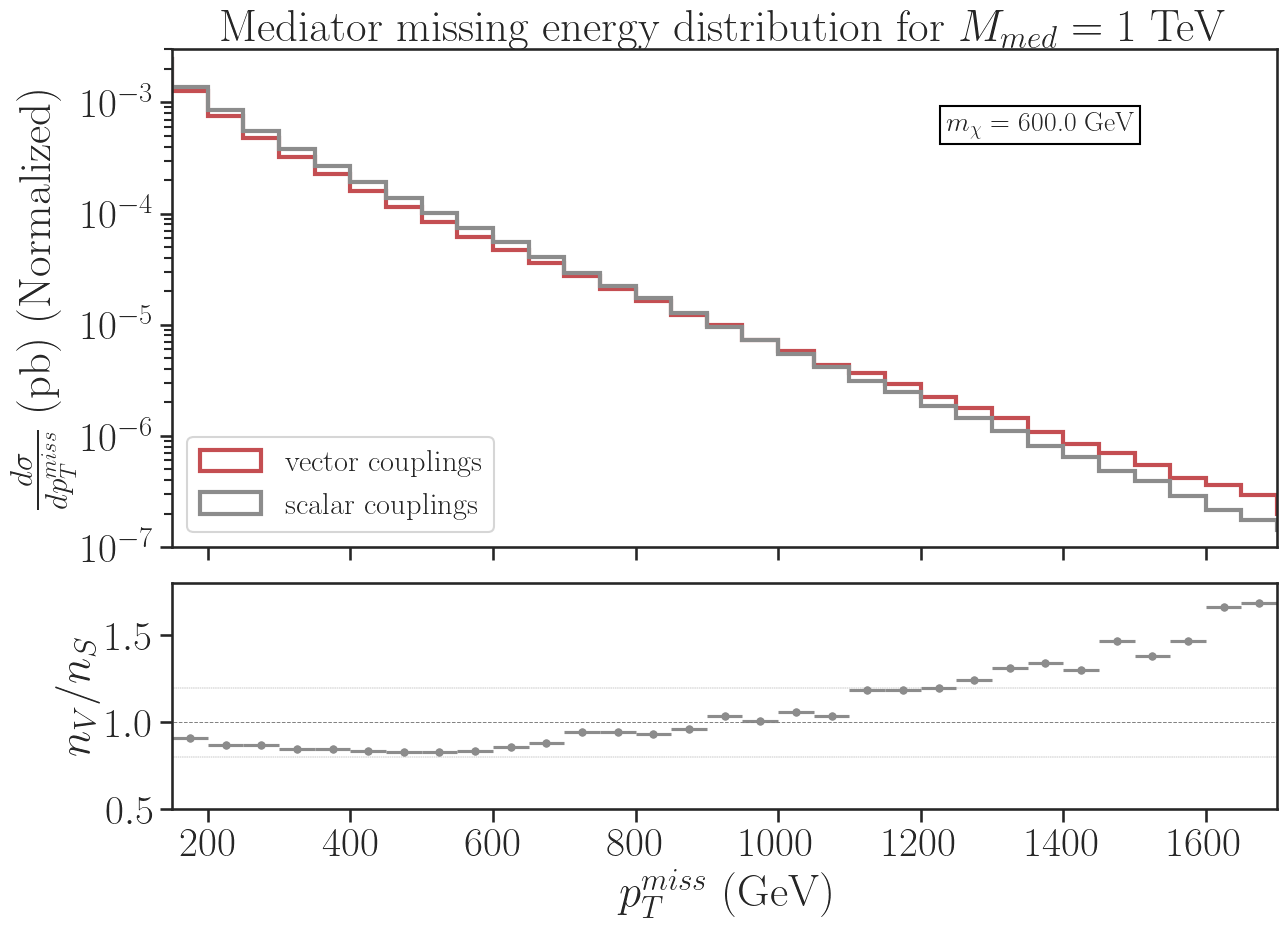

In [32]:
figs, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2.2, 1]},figsize=(13,10))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

for label,metPts in met.items():
    if label in ['vector_run04']:
        bincS1,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=3, density=True)
        errorS1, _ = np.histogram(metPts,bins=binEdges,weights=weights[label]**2)
        
for label,metPts in met.items():
    if label in ['scalar_run04']:
        k = totalweight['vector_run04']/totalweight[label]
        binc,binEdges,patches = ax[0].hist(metPts,bins=np.linspace(0,5000,101),
                                        label=r'%s couplings' %(label.split('_')[0]),
                                         histtype='step',color=colors[label],
                                         weights=weights[label],linewidth=3, density=True)
        binCenter = (binEdges[0:-1]+binEdges[1:])/2.
        errorh = (np.diff(binEdges+[2000.])/2).tolist()
        errorL, _ =  np.histogram(metPts,bins=binEdges,weights=weights[label]**2) 
        
        ratio = bincS1/binc
        ratioErr = np.sqrt(errorS1**2 + ratio**2 * errorL**2)/binc


        ax[1].scatter(binCenter, ratio, marker='.', label=r'%s couplings' %(label.split('_')[0]),
                      color=colors[label])
        ax[1].errorbar(binCenter,ratio, xerr=errorh, yerr = ratioErr, fmt='.', color=colors[label])

        
    
        
ax[0].text(0.7,3,r'$m_{\chi} =$ %.1f GeV' %parameters['scalar_run04']['mDM'],
           fontsize=20,bbox=dict(facecolor='none', edgecolor='black'),transform = plt.gca().transAxes)
ax[1].hlines(y=1, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.7)
ax[1].hlines(y=1.2, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
ax[1].hlines(y=0.8, xmin=0, xmax=2000., linestyle='--', color='gray', linewidth=0.3)
    
ax[0].set_yscale('log')
ax[0].set_ylim(1e-7,3e-3)
ax[0].set_ylabel(r'$\frac{d\sigma}{d p_T^{miss}}$ (pb) (Normalized)')
ax[0].set_xlim(150,1700)
ax[0].legend(loc='lower left', fontsize=22)
ax[0].set_title(r'Mediator missing energy distribution for $M_{med} = 1$ TeV')
ax[0].tick_params()


ax[1].tick_params()
ax[1].set_ylim(0.5,1.8)
ax[1].set_xlabel(r'$p_T^{miss}$ (GeV)')
ax[1].set_ylabel(r'$n_{V}/n_{S}$')

plt.savefig('plot-s-ps-v-av-mxd600.png', dpi=600)
plt.show()

In [23]:
ratioErr

array([2.75031171e-05, 6.18180728e-06, 1.93274017e-06, 8.68645885e-07,
       4.95844049e-07, 3.27708967e-07, 2.27724688e-07, 1.69658040e-07,
       1.30544544e-07, 1.03147759e-07, 8.46770934e-08, 7.10531165e-08,
       6.16712741e-08, 5.42753233e-08, 5.02493418e-08, 4.41335534e-08,
       3.85199882e-08, 3.51750676e-08, 3.38878753e-08, 2.95943046e-08,
       2.81988394e-08, 2.51052917e-08, 2.62150654e-08, 2.39386362e-08,
       2.23642630e-08, 2.13840125e-08, 2.09629354e-08, 1.98039259e-08,
       1.78706822e-08, 1.88183626e-08, 1.66440708e-08, 1.64828066e-08,
       1.76279353e-08, 1.68168720e-08, 1.32200798e-08, 1.60411681e-08,
       1.41908551e-08, 1.38921760e-08, 1.25068607e-08, 1.37231823e-08,
       1.11534951e-08, 1.20713292e-08, 1.02771378e-08, 1.82055352e-08,
       7.83635578e-09, 7.24586807e-09, 1.13214288e-08, 1.43201630e-08,
       1.36966192e-08, 9.37134401e-09, 5.67803146e-09, 5.09716825e-09,
       1.86489380e-08, 9.13969747e-09, 2.12114808e-08, 2.22895904e-09,
      

In [24]:

# inputFiles = {'axial_nnlo_01': '../DMSimp_axial_parton/Events/run_17/unweighted_events.lhe.gz',
#               'axial_lo_01': '../DMSimp_axial_parton/Events/run_16/unweighted_events.lhe.gz',
#               'axial_lo_02': '../DMSimp_axial_parton/Events/run_15/unweighted_events.lhe.gz',
#               'axial_nnlo_02': '../DMSimp_axial_parton/Events/run_14/unweighted_events.lhe.gz',
#               'axial_nnlo_03': 